# Publication Figures and Metrics

This notebook demonstrates the use of the `reionemu` Python package and is the notebook that generated the figures for the publication.

## Imports
---

In [1]:
import sys
from pathlib import Path

from scipy.interpolate import LinearNDInterpolator
from scipy.stats import norm, spearmanr
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import h5py
import numpy as np
import time
import torch
from torch.utils.data import DataLoader, Subset, TensorDataset
import pandas as pd
import emcee
import corner

import reionemu
from reionemu import (
    CondenseConfig,
    CondenseStats,
    condense_sim_root,
    ClConfig,
    add_cl_to_condensed_h5,
    BuildXYConfig,
    BuildStats,
    build_and_write_training,
    load_training_arrays,
    DataLoaderConfig,
    make_dataloaders,
    Normalizer,
    MCDropoutEmulator,
    FitConfig,
    fit,
    evaluate_mc_metrics,
    evaluate_metrics,
    mse, rmse, physical_mean_relative_error,
    KFoldConfig,
    kfold_cross_validate,
    save_artifact,
)

%pip install tqdm


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: /Users/robertxpearce/Desktop/Research/LEADS Lab/Reionization Emulator/Code/reionization-emulator/.venv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Figure Settings
---

In [2]:
plt.style.use("default")

plt.rcParams.update({
    "figure.figsize": (3.35, 2.5),
    "font.size": 9,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
})

# Run Experiment
---

In [84]:
N_MC_PLOT = 201
N_MC_EVAL = 201
EPOCHS = 1000
EARLY_STOP = 150

# if torch.backends.mps.is_available():
#     device = "mps"
# elif torch.cuda.is_available():
#     device = "cuda"
# else:
#     device = "cpu"

device = "cpu"

print(f"Device: {device}")

Device: cpu


In [4]:
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Python:\t\t{sys.version.split()[0]}")
print("-" * 30)
print(f"NumPy:\t\t{np.__version__}")
print(f"PyTorch:\t{torch.__version__}")
print(f"h5py:\t\t{h5py.version.version}")
print(f"emcee:\t\t{emcee.__version__}")
print(f"corner:\t\t{corner.__version__}")
print(f"pandas:\t\t{pd.__version__}")
print("-" * 30)
print(f"Global Seed:\t{SEED}")

Python:		3.13.1
------------------------------
NumPy:		2.4.3
PyTorch:	2.10.0
h5py:		3.16.0
emcee:		3.1.6
corner:		2.2.3
pandas:		3.0.1
------------------------------
Global Seed:	42


In [5]:
RAW_PATH = Path("../datasets/raw/sims_v6").resolve()
H5_PATH = Path("../datasets/processed/publication_condensed_v6.h5").resolve()

EXPERIMENT_NAME = f"n_mc_{N_MC_PLOT}_epochs_{EPOCHS}_early_stop_{EARLY_STOP}"

CKPT_DIR = Path(f"../checkpoints/pearce_2026_reionemu_mc_dropout/mc_dropout_{EXPERIMENT_NAME}").resolve()
MODEL_PATH = CKPT_DIR / "model.pt"
NORM_PATH = CKPT_DIR / "norm"

FIG_DIR = Path(f"../results/pearce_2026_reionemu_mc_dropout/{EXPERIMENT_NAME}").resolve()
FIG_DIR.mkdir(parents=True, exist_ok=True)

ARTIFACT_DIR = Path(f"../artifacts/pearce_2026_reionemu_mc_dropout").resolve()

In [6]:
PARAM_BOUNDS = np.array([
    [7.0, 9.0],
    [0.10, 0.90],
    [0.10, 2.0],
    [0.10, 0.80],
])

param_labels = [r"$\bar{z}$", r"$\alpha$", r"$k_b$", r"$b_0$"]

## MCMC Execution Control
---
The four MCMC blocks dominate the runtime.

The blocks are independent: the random-case, central-case and SBC blocks run
their own chains rather than reusing the single chain.


In [82]:
# Chain on the most-central held-out sim -> corner plot, tau posterior, ionization history 
RUN_SINGLE_MCMC = True
# Chains on randomly chosen held-out sims -> random-case ionization-history figure
RUN_RANDOM_CASES = True
# Chains on the held-out sims nearest the center of parameter space -> central-case figure
RUN_CENTRAL_CASES = False
# 100 chains, noise drawn and walkers started from the prior -> SBC rank histograms
RUN_SBC = False

print(f"RUN_SINGLE_MCMC\t\t= {RUN_SINGLE_MCMC}")
print(f"RUN_RANDOM_CASES\t= {RUN_RANDOM_CASES}")
print(f"RUN_CENTRAL_CASES\t= {RUN_CENTRAL_CASES}")
print(f"RUN_SBC\t\t\t\t= {RUN_SBC}")

RUN_SINGLE_MCMC		= True
RUN_RANDOM_CASES	= True
RUN_CENTRAL_CASES	= False
RUN_SBC				= False


## Build Condensed Dataset

In [8]:
%%time

cdcfg = CondenseConfig(
    overwrite=True,
    require_obs_and_pk=True,
)

condense_stats = condense_sim_root(
    sim_root=RAW_PATH,
    out_path=H5_PATH,
    config=cdcfg,
    file_description="Condensed simulation dataset for publication figures.",
    version=1,
)

print(condense_stats)

CondenseStats(written=1000, skipped_missing_obs_pk=0, skipped_read_error=0, skipped_validation_error=0)
CPU times: user 1.26 s, sys: 6.76 s, total: 8.02 s
Wall time: 13.3 s


In [9]:
%%time

clcfg = ClConfig(
    nbins=5,
    ell_cut=1000.0,
    overwrite=True,
)

cl_stats = add_cl_to_condensed_h5(
    h5_path=H5_PATH,
    config=clcfg,
)

print(cl_stats)

1000
CPU times: user 2min 58s, sys: 2.44 s, total: 3min
Wall time: 3min 9s


In [10]:
%%time

xycfg = BuildXYConfig(
    param_names=("zmean_zre", "alpha_zre", "kb_zre", "b0_zre"),
    y_source="dl_ksz",
    y_transform="ln",
    eps=1e-30,
)

xy_stats = build_and_write_training(
    h5_path=H5_PATH,
    config=xycfg,
    overwrite=True,
)

print(xy_stats)

1000
CPU times: user 226 ms, sys: 32.5 ms, total: 259 ms
Wall time: 404 ms


## Prepare Data

In [11]:
dlcfg = DataLoaderConfig(
    batch_size=32,
    seed=SEED,
    shuffle_train=True,
    normalize_X=True,
    normalize_Y=False,
)

loaders, norms, ell = make_dataloaders(
    h5_path=H5_PATH,
    split={"train": 0.70, "val": 0.10, "test": 0.20},
    config=dlcfg,
)
print(loaders)
print(norms)
print(ell)

{'train': <torch.utils.data.dataloader.DataLoader object at 0x11f6e34d0>, 'val': <torch.utils.data.dataloader.DataLoader object at 0x11f687b10>, 'test': <torch.utils.data.dataloader.DataLoader object at 0x11f687ed0>}
{'X': Normalizer(mean=array([7.9980483 , 0.49714097, 1.06111   , 0.45881906], dtype=float32), std=array([0.5698338, 0.2326668, 0.5521792, 0.2050817], dtype=float32)), 'Y': None}
[ 2033.4963  4093.4153  6153.3345  8213.253  10273.172 ]


## Prepare Model

In [12]:
modelcfg = {
    "input_dim": 4,
    "output_dim": 5,
    "hidden_dim": 20,
    "num_hidden_layers": 2,
    "activation": "relu",
    "dropout_rate":0.1,
}

model = MCDropoutEmulator(**modelcfg)
lossfn = torch.nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

model

MCDropoutEmulator(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=20, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=20, out_features=20, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=20, out_features=5, bias=True)
  )
)

# K-Fold Cross-Validation
---
Fold losses below are scored with a single deterministic forward pass with **dropout off**. This isolates the architecture and optimizer from the stochasticity of MC dropout, so the fold-to-fold spread measures how robust the architecture is to the choice of training split.

In [13]:
%%time

def build_model():
    return MCDropoutEmulator(
        input_dim=4,
        output_dim=5,
        hidden_dim=20,
        num_hidden_layers=2,
        activation="relu",
        dropout_rate=0.1,
    )

def build_optimizer(model):
    return torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

def build_lossfn():
    return torch.nn.MSELoss()


fitcfg = FitConfig(
    epochs=EPOCHS,
    device=device,
    early_stopping_patience=EARLY_STOP,
    gradient_clipping=None,
)

kfcfg = KFoldConfig(
    k=5,
    seed=SEED,
    return_histories=True,
)

kfold_results = kfold_cross_validate(
    h5_path=H5_PATH,
    model_builder=build_model,
    optimizer_builder=build_optimizer,
    loss_fn=build_lossfn(),
    kfold_config=kfcfg,
    dl_config=dlcfg,
    fit_config=fitcfg,
)

print(kfold_results.keys())
print(f"Min Validation Loss Per Fold: {kfold_results['fold_best_val']}")
print(f"Mean Validation Loss (MSE): {kfold_results['mean_best_val']}")
print(f"STD Validation Loss: {kfold_results['std_best_val']}")


=== Fold 1/5 | train=800 val=200 ===
Epoch 001: train=0.296304, val=0.265049
Epoch 002: train=0.238211, val=0.209013
Epoch 003: train=0.182250, val=0.144832
Epoch 004: train=0.124684, val=0.081755
Epoch 005: train=0.078094, val=0.045045
Epoch 006: train=0.056903, val=0.032002
Epoch 007: train=0.050211, val=0.026206
Epoch 008: train=0.045585, val=0.021998
Epoch 009: train=0.041667, val=0.019807
Epoch 010: train=0.038759, val=0.017326
Epoch 011: train=0.036990, val=0.016150
Epoch 012: train=0.033968, val=0.015129
Epoch 013: train=0.032240, val=0.013622
Epoch 014: train=0.032470, val=0.013106
Epoch 015: train=0.029369, val=0.012749
Epoch 016: train=0.028137, val=0.012553
Epoch 017: train=0.030360, val=0.011879
Epoch 018: train=0.026676, val=0.011666
Epoch 019: train=0.023356, val=0.011606
Epoch 020: train=0.028653, val=0.010412
Epoch 021: train=0.024056, val=0.010395
Epoch 022: train=0.024034, val=0.010422
Epoch 023: train=0.023420, val=0.009943
Epoch 024: train=0.021332, val=0.009924
Ep

## K-Fold Cross-Validation: Validation Loss Per Fold

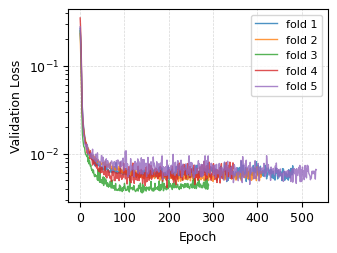

In [14]:
fig, ax = plt.subplots()

for i, h in enumerate(kfold_results["histories"]):
    ax.plot(h["val_loss"], label=f"fold {i + 1}", alpha=0.8, linewidth=1.0)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss")
ax.set_yscale("log")

ax.legend(fontsize=8)

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

fig.savefig(FIG_DIR / f'validation_loss_per_fold_{EXPERIMENT_NAME}.pdf', format='pdf', bbox_inches="tight")

plt.show()

## K-Fold Cross-Validation: Min Val Loss Per Fold

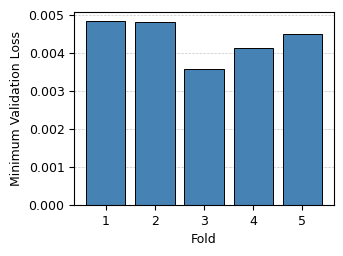

In [15]:
best_vals = np.array(kfold_results["fold_best_val"], dtype=float)
mean_val = kfold_results['mean_best_val']

fig, ax = plt.subplots()

ax.bar(np.arange(1, len(best_vals) + 1), best_vals, color='steelblue', alpha=1, edgecolor='black', linewidth=0.7)

ax.set_xlabel("Fold")
ax.set_ylabel("Minimum Validation Loss")

ax.set_xticks(np.arange(1, len(best_vals) + 1))

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

fig.savefig(FIG_DIR / f'best_validation_loss_per_fold_{EXPERIMENT_NAME}.pdf', format='pdf', bbox_inches="tight")
plt.show()

## K-Fold Cross-Validation: Metrics

In [16]:
print(f"Best Validation Loss Per Fold:\n\t{best_vals}")
print(f"Mean Validation Loss Across Folds:\n\t{mean_val:.4f}")
print(f"STD of Validation Loss Across Folds:\n\t{best_vals.std():.4f}")

Best Validation Loss Per Fold:
	[0.0048194  0.00479738 0.00357987 0.0041269  0.00447956]
Mean Validation Loss Across Folds:
	0.0044
STD of Validation Loss Across Folds:
	0.0005


# Supervised Training
---

## Predict Function

In [17]:
def enable_dropout_only(model):
    for module in model.modules():
        if isinstance(module, torch.nn.Dropout):
            module.train()

def predict_mc(
    params,
    model,
    X_mean=None,
    X_std=None,
    Y_mean=None,
    Y_std=None,
    *,
    normalize_X=True,
    normalize_Y=False,
    n_mc_samples=100,
):
    params = np.asarray(params, dtype=np.float32)

    if normalize_X:
        params = (params - X_mean) / X_std

    xb = torch.from_numpy(params.astype(np.float32)).to(device)

    model.eval()
    enable_dropout_only(model)
    with torch.no_grad():
        samples = torch.stack([model(xb) for _ in range(n_mc_samples)], dim=0)

    samples_log = samples.cpu().numpy()
    if normalize_Y:
        samples_log = samples_log * Y_std + Y_mean

    samples_dl = np.exp(samples_log)
    pred_mean = samples_dl.mean(axis=0)
    pred_std = samples_dl.std(axis=0, ddof=1)

    return pred_mean, pred_std, samples_dl, samples_log

## Train Model

In [18]:
%%time

np.random.seed(SEED)
torch.manual_seed(SEED)

model = MCDropoutEmulator(**modelcfg)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
lossfn = torch.nn.MSELoss()

fitcfg = FitConfig(
    epochs=EPOCHS,
    device=device,
    early_stopping_patience=EARLY_STOP,
    gradient_clipping=None,
    seed=SEED,
)

train_results = fit(
    model,
    loaders["train"],
    loaders["val"],
    optimizer,
    lossfn,
    fitcfg,
    metrics={"Physical Mean Relative Error": physical_mean_relative_error, "RMSE": rmse, "MSE": mse},
    evaluation="evaluate_mc_metrics",
    n_mc_samples=100,
)

print(train_results)

Epoch 001: train=0.290863, val=0.289316, Physical Mean Relative Error=0.554303, RMSE=0.535067, MSE=0.289316, predictive_std=0.042981
Epoch 002: train=0.242863, val=0.242821, Physical Mean Relative Error=0.491692, RMSE=0.489698, MSE=0.242821, predictive_std=0.051744
Epoch 003: train=0.193949, val=0.190397, Physical Mean Relative Error=0.414574, RMSE=0.432519, MSE=0.190397, predictive_std=0.067701
Epoch 004: train=0.141113, val=0.130392, Physical Mean Relative Error=0.319922, RMSE=0.356318, MSE=0.130392, predictive_std=0.088293
Epoch 005: train=0.096846, val=0.080220, Physical Mean Relative Error=0.229797, RMSE=0.277647, MSE=0.080220, predictive_std=0.112097
Epoch 006: train=0.061285, val=0.054788, Physical Mean Relative Error=0.178803, RMSE=0.228789, MSE=0.054788, predictive_std=0.123673
Epoch 007: train=0.051801, val=0.044143, Physical Mean Relative Error=0.156909, RMSE=0.205131, MSE=0.044143, predictive_std=0.128823
Epoch 008: train=0.049032, val=0.036857, Physical Mean Relative Error

## Training: MSE Loss Over Epoch & Mean Predictive STD Over Epoch

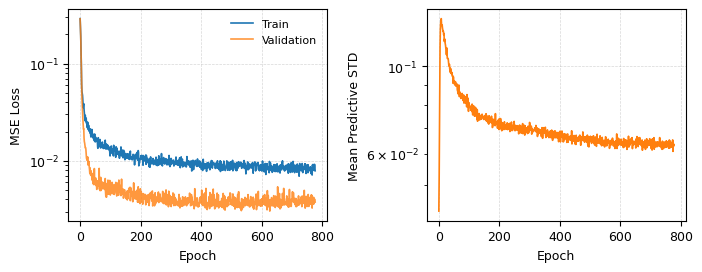

Train Loss: [0.29086271984236584, 0.24286276970590864, 0.19394919914858683, 0.14111343000616347, 0.0968456734078271, 0.06128468585865838, 0.05180111914873123, 0.04903233770813261, 0.0471694073506764, 0.041859138022576056, 0.03518081586275782, 0.037711588059152874, 0.03872046546212264, 0.03368040180632046, 0.031245796637875693, 0.029238487343702997, 0.026307549849152564, 0.029446399488619397, 0.025453054415328163, 0.02748546687620027, 0.0275265154668263, 0.024326180613466673, 0.02500457586986678, 0.02270756891795567, 0.02188641750386783, 0.024957607138369763, 0.021974537010703767, 0.020953421374516827, 0.023230532524841172, 0.02154947987624577, 0.02014464395386832, 0.021151196275438582, 0.020227856162403312, 0.019273617597562926, 0.021308803302901132, 0.0182513652741909, 0.017549477336662157, 0.019098558197064058, 0.018754861961518016, 0.021017167270183563, 0.018900615594216755, 0.019172220740999495, 0.017591513214366777, 0.017770274973341396, 0.016893836286451136, 0.01714387182678495, 

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(7.1, 2.8))

# Loss
ax[0].plot(train_results["train_loss"], label="Train", linewidth=1.2)
ax[0].plot(train_results["val_loss"], label="Validation", linewidth=1.2, alpha=0.8)

ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("MSE Loss")
ax[0].set_yscale("log")

# ax[0].set_title("(a)", loc="left", fontweight="bold")

ax[0].legend(frameon=False, fontsize=8)
ax[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.5)


# MC-Dropout Uncertainty
ax[1].plot(train_results["val_mean_predictive_std"], color="tab:orange", linewidth=1.2)

ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Mean Predictive STD")
ax[1].set_yscale("log")

# ax[1].set_title("(b)", loc="left", fontweight="bold")

ax[1].grid(True, linestyle='--', linewidth=0.5, alpha=0.5)


plt.tight_layout()

fig.savefig(FIG_DIR / f'training_loss_and_mc_dropout_uncertainty_{EXPERIMENT_NAME}.pdf', format='pdf', bbox_inches="tight")
plt.show()

print(f"Train Loss: {train_results['train_loss']}\n")
print(f"Validation Loss: {train_results['val_loss']}\n")
print(f"Mean Predictive STD: {train_results['val_mean_predictive_std']}")

### Number of Epochs

In [96]:
best_epoch = int(np.argmin(train_results["val_loss"]))
print(f"Number of Epochs: {len(train_results['train_loss'])}")
print(f"Best epoch (restored checkpoint): {best_epoch + 1}")
print(f"\ttrain = {train_results['train_loss'][best_epoch]:.5f}")
print(f"\tval = {train_results['val_loss'][best_epoch]:.5f}")
print(f"\tmean predictive std = {train_results['val_mean_predictive_std'][best_epoch]:.5f}")

Number of Epochs: 778
Best epoch (restored checkpoint): 628
	train = 0.00906
	val = 0.00304
	mean predictive std = 0.06655


## Validation Loss: Like-for-Like Comparison

The k-fold section scores folds deterministically (dropout off); the training run scores the MC-dropout predictive mean (dropout on). Two things differ between those numbers - the evaluation protocol and which metric selected the checkpoint. This cell separates them by measuring both effects instead of asserting one.


In [94]:
assert not dlcfg.normalize_Y, "fold loaders below assume raw Y; refit Y norms per fold"

final_val_deterministic = evaluate_metrics(model, loaders["val"], lossfn, device)["loss"]
final_val_mc = evaluate_mc_metrics(model, loaders["val"], lossfn, device, n_mc_samples=N_MC_EVAL)["loss"]

X_kf, Y_kf, _ = load_training_arrays(H5_PATH)

fold_det, fold_mc = [], []
for fold_model, fold_norm, fold_val_idx in zip(kfold_results["models"], kfold_results["norms"], kfold_results["val_indices"]):
    X_fold = (X_kf if fold_norm["X"] is None else (X_kf - fold_norm["X"].mean) / fold_norm["X"].std)
    fold_loader = DataLoader(
        Subset(TensorDataset(torch.from_numpy(X_fold.astype(np.float32)), torch.from_numpy(Y_kf)), fold_val_idx.tolist()),
        batch_size=dlcfg.batch_size,
        shuffle=False,
    )
    fold_det.append(evaluate_metrics(fold_model, fold_loader, lossfn, device)["loss"])
    fold_mc.append(evaluate_mc_metrics(fold_model, fold_loader, lossfn, device, n_mc_samples=N_MC_EVAL)["loss"])

fold_det, fold_mc = np.asarray(fold_det), np.asarray(fold_mc)
fold_mean, fold_spread = fold_det.mean(), fold_det.std(ddof=1)
gap_sigma = abs(final_val_deterministic - fold_mean) / fold_spread

print(f"K-Fold, Deterministic: \t\t\t {fold_mean:.5f} +- {fold_spread:.5f} \t (CV {100 * fold_spread / fold_mean:.1f}%)")
print()
print(f"Final Model, Deterministic: \t {final_val_deterministic:.5f}")
print()
print(f"Final Model, MC-dropout Mean: \t {final_val_mc:.5f}")
print(f"\nMC ensembling with selection held fixed (fold models): {100 * (fold_mc.mean() / fold_mean - 1.0):+.0f}%")

K-Fold, Deterministic: 			 0.00436 +- 0.00052 	 (CV 11.9%)

Final Model, Deterministic: 	 0.00433

Final Model, MC-dropout Mean: 	 0.00323

MC ensembling with selection held fixed (fold models): +2%


# Error and Uncertainty Metrics
---

## Separate Held-Out Set

In [22]:
X, Y, ell = load_training_arrays(H5_PATH)

heldout_indices = np.asarray(loaders["test"].dataset.indices, dtype=int)
X_heldout = X[heldout_indices]
Y_heldout = Y[heldout_indices]

print(f"Held-out Samples:\t\t{len(heldout_indices)}")
print(heldout_indices)

Held-out Samples:		200
[560 481 499 323  93 843 877 763 389 397 564  32 386 364 667 453 440 640
 633 227 369 642 416 452  81 827 820 863 370 311 450  52 912 342 540 267
 721 106 122 396 992 533 730 384 105 266 347 190 864 850  39 339 188 403
 525 189 812  87 732 483   5 597 699 953 442 893 861 385 332 790 359 590
 504 962 375 114 170 851 123 301 615 602 711 786 918 508 718 599 221 654
 111 475 484 329 279 277 349 956 187  65 974 611 583 948  69 410 689 637
 177 736 982 117 586 372  10 628 927 669  63 735 500   1  42 634 529 167
 809 821  76 313 296 502 490 720 837 543 641 939 617 290 779 910 212 555
 967 672 317  57 791 535 932 272  15 432 503 828 621 137 702 287 451 528
 300 752 622 943 195  34 286 314 970 547 333 182  49 518 102 687 651  41
 553 366 534 275 675 832 303 113 749 908 437 491 526 141 706 548 609 961
 973 648]


## Make Predictions

In [23]:
pred_mean, pred_std, samples_dl, samples_log = predict_mc(
    X_heldout,
    model,
    norms["X"].mean,
    norms["X"].std,
    normalize_X=True,
    n_mc_samples=N_MC_PLOT,
)

true = np.exp(Y_heldout)

# Aliased under held-out-specific names
heldout_pred_mean = pred_mean
heldout_pred_std = pred_std

## Test-Set Mean Absolute Percentage Error (%) | Mean Squared Error (MSE) | Mean Absolute Error (MAE)

In [24]:
absolute_relative_error = np.abs((pred_mean - true) / true)
mean_absolute_relative_error = np.mean(np.abs((pred_mean - true) / true))
percent_err = mean_absolute_relative_error * 100

test_mse = np.mean((pred_mean - true) ** 2)
test_rmse = np.sqrt(test_mse)
test_mae = np.mean(np.abs(pred_mean - true))

print(f"Mean Absolute Percentage Error (MAPE):\t{percent_err:.2f}")
print(f"Mean Squared Error (MSE):\t\t\t\t{test_mse:.4f}")
print(f"Root Mean Squared Error (RMSE):\t\t\t{test_rmse:.4f}")
print(f"Mean Absolute Error (MAE):\t\t\t\t{test_mae:.4f}")

Mean Absolute Percentage Error (MAPE):	5.07
Mean Squared Error (MSE):			0.0040
Root Mean Squared Error (RMSE):		0.0630
Mean Absolute Error (MAE):			0.0451


## MC-Dropout Predictive Uncertainty Coverage

In [25]:
phy_coverage_1sigma = np.mean(np.abs(pred_mean - true) <= pred_std) * 100
phy_coverage_2sigma = np.mean(np.abs(pred_mean - true) <= 2.0 * pred_std) * 100
phy_coverage_3sigma = np.mean(np.abs(pred_mean - true) <= 3.0 * pred_std) * 100
z_score = np.abs(pred_mean - true) / pred_std

print("1-Sigma Coverage:\t", phy_coverage_1sigma)
print("2-Sigma Coverage:\t", phy_coverage_2sigma)
print("3-Sigma Coverage:\t", phy_coverage_3sigma)
print()
print(np.mean(z_score <= 1))
print(np.mean(z_score <= 2))
print(np.mean(z_score <= 3))
print(np.percentile(z_score, [50, 68, 90, 95, 99]))
print(np.max(z_score))

1-Sigma Coverage:		 66.9
2-Sigma Coverage:		 89.9
3-Sigma Coverage:		 97.2

0.669
0.899
0.972
[0.66560876 1.0426828  2.00197427 2.58417863 3.93633229]
4.8043084


## Uncertainty Calibration Diagnostics
Marginal coverage can be correct while sigma carries no per-point information. Spearman rank correlation, coverage per sigma-quintile, and a reliability curve test that separately.
- Spearman(sigma, |error|) - does sigma rank-order the actual errors?
- Coverage Per Sigma-Quintile - is coverage uniform across the sigma range?
- Reliability Curve - empirical vs nominal coverage at all levels

Does sigma predict WHICH points are wrong?
	Spearman(sigma, |err|) per bandpower:	+0.290
	Spearman(sigma, |err|) per simulation:	-0.046
	1.0 = perfect ranking, 0.0 = sigma carries no per-point information

1-sigma coverage by predictive-sigma quintile (ideal 68.3% in every bin):
	quintile           sigma range  coverage %
	Q1              [0.020, 0.032]        55.0
	Q2              [0.032, 0.040]        67.0
	Q3              [0.040, 0.052]        66.5
	Q4              [0.052, 0.071]        69.0
	Q5              [0.071, 0.229]        77.0

Expected calibration error, mean |empirical - nominal|: 1.99%


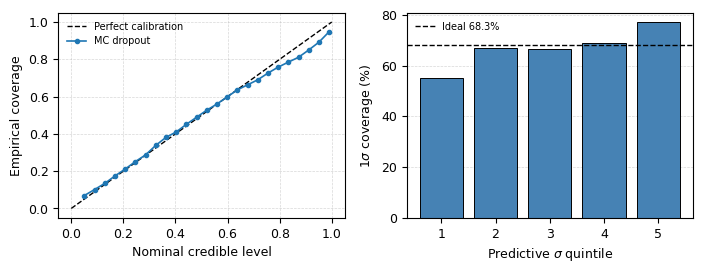

In [26]:
def calibration_summary(name, pred, sd):
    """Accuracy + calibration diagnostics for one emulator, in physical units."""
    err = np.abs(pred - true)
    frac = (pred - true) / true
    z = (err / sd).ravel()
    sd_flat = sd.ravel()

    # coverage within each quintile of predictive sigma
    q_edges = np.quantile(sd_flat, np.linspace(0.0, 1.0, 6))
    quintiles = [
        np.mean(z[(sd_flat >= q_edges[i]) & (sd_flat <= q_edges[i + 1])] <= 1.0) * 100
        for i in range(5)
    ]

    # reliability: empirical coverage of the central `a` interval, for many a
    nominal = np.linspace(0.05, 0.99, 25)
    empirical = np.array([np.mean(z <= norm.ppf(0.5 + a / 2.0)) for a in nominal])

    return {
        "name": name,
        "mape": np.mean(np.abs(frac)) * 100,
        "rms": np.sqrt(np.mean(frac**2)) * 100,
        "coverage": [np.mean(z <= k) * 100 for k in (1, 2, 3)],
        "rho_bin": spearmanr(sd_flat, err.ravel()).statistic,
        "rho_sim": spearmanr(sd.mean(axis=1), np.abs(frac).mean(axis=1)).statistic,
        "quintiles": quintiles,
        "q_edges": q_edges,
        "nominal": nominal,
        "empirical": empirical,
        "ece": np.mean(np.abs(empirical - nominal)) * 100,
    }


mc_cal = calibration_summary("MC dropout", pred_mean, heldout_pred_std)

print("Does sigma predict WHICH points are wrong?")
print(f"\tSpearman(sigma, |err|) per bandpower:\t{mc_cal['rho_bin']:+.3f}")
print(f"\tSpearman(sigma, |err|) per simulation:\t{mc_cal['rho_sim']:+.3f}")
print("\t1.0 = perfect ranking, 0.0 = sigma carries no per-point information")

print("\n1-sigma coverage by predictive-sigma quintile (ideal 68.3% in every bin):")
print(f"\t{'quintile':<10}{'sigma range':>20}{'coverage %':>12}")
for i, c in enumerate(mc_cal["quintiles"]):
    lo, hi = mc_cal["q_edges"][i], mc_cal["q_edges"][i + 1]
    print(f"\tQ{i + 1:<9}{f'[{lo:.3f}, {hi:.3f}]':>20}{c:>12.1f}")

print(f"\nExpected calibration error, mean |empirical - nominal|: {mc_cal['ece']:.2f}%")

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(7.1, 2.8))

ax[0].plot([0, 1], [0, 1], "k--", linewidth=1.0, label="Perfect calibration")
ax[0].plot(
    mc_cal["nominal"], mc_cal["empirical"],
    marker="o", markersize=3, linewidth=1.2, color="tab:blue", label="MC dropout",
)
ax[0].set_xlabel("Nominal credible level")
ax[0].set_ylabel("Empirical coverage")
ax[0].legend(frameon=False, fontsize=7)
ax[0].grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

ax[1].bar(
    np.arange(1, 6), mc_cal["quintiles"],
    color="steelblue", edgecolor="black", linewidth=0.7,
)
ax[1].axhline(68.3, color="black", linestyle="--", linewidth=1.0, label="Ideal 68.3%")
ax[1].set_xlabel(r"Predictive $\sigma$ quintile")
ax[1].set_ylabel(r"$1\sigma$ coverage (%)")
ax[1].set_xticks(np.arange(1, 6))
ax[1].legend(frameon=False, fontsize=7)
ax[1].set_axisbelow(True)
ax[1].grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
fig.savefig(
    FIG_DIR / f"calibration_diagnostics_{EXPERIMENT_NAME}.pdf",
    format="pdf", bbox_inches="tight",
)
plt.show()

## Gaussian Process Baseline
The standard emulator for a 4-input, 700-point cosmology design, with a
closed-form predictive variance. Establishes whether the MC-dropout accuracy
and calibration are good in absolute terms.


In [27]:
%%time
# Gaussian-process baseline.
#
# A GP is the standard emulator for a low-dimensional, small-N cosmology design
# (4 inputs, 700 training points) and it yields a closed-form predictive variance
# instead of MC dropout's heuristic one. Without this comparison there is no way
# to tell whether the network's accuracy and calibration are good in absolute
# terms or merely internally consistent.
#
# Strict comparison: the GP sees only the 700-sim training split. The network
# additionally used the 100-sim validation split for early stopping, so if
# anything this favours the network.
#
# One independent GP per bandpower, ARD Matern-5/2 plus a white-noise term. ARD
# gives a per-input length scale, which doubles as a relevance measure. sklearn's
# random_state is set explicitly and no torch RNG is touched, so this cell cannot
# perturb any downstream MC-dropout result.

import warnings

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

train_indices = np.asarray(loaders["train"].dataset.indices, dtype=int)
X_train_norm = (X[train_indices] - norms["X"].mean) / norms["X"].std
X_heldout_norm = (X_heldout - norms["X"].mean) / norms["X"].std

gp_mu, gp_sd_log, gp_noise_var, gp_kernels = [], [], [], []

with warnings.catch_warnings():
    # L-BFGS occasionally reports ABNORMAL on one bandpower; the restarts make
    # the fit robust and the recovered hyperparameters are inspected below.
    warnings.simplefilter("ignore")

    for b in range(Y.shape[1]):
        kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
            length_scale=np.ones(4), length_scale_bounds=(1e-2, 1e3), nu=2.5
        ) + WhiteKernel(1e-3, (1e-12, 1e0))

        gp = GaussianProcessRegressor(
            kernel=kernel,
            normalize_y=True,
            n_restarts_optimizer=10,
            random_state=SEED,
        )
        gp.fit(X_train_norm, Y[train_indices, b])

        mu, sd = gp.predict(X_heldout_norm, return_std=True)
        gp_mu.append(mu)
        gp_sd_log.append(sd)
        # normalize_y standardises the target, so noise_level is expressed in
        # units of var(y_train); rescale it back into ln D_ell units.
        gp_noise_var.append(gp.kernel_.k2.noise_level * Y[train_indices, b].var())
        gp_kernels.append(gp.kernel_)

gp_mu = np.column_stack(gp_mu)
gp_sd_log = np.column_stack(gp_sd_log)
gp_noise_var = np.asarray(gp_noise_var)

# The GP posterior is Gaussian in ln D_ell, so D_ell is lognormal. Convert
# analytically instead of by sampling - that closed form is the GP's advantage.
gp_pred_mean = np.exp(gp_mu + 0.5 * gp_sd_log**2)
gp_pred_std = gp_pred_mean * np.sqrt(np.expm1(gp_sd_log**2))

print("ARD length scales per bandpower (standardised inputs span roughly +-1.75)")
header = f"{'bin':<5}{'ell':>7}" + "".join(
    f"{n:>9}" for n in ("z-bar", "alpha", "k_b", "b_0")
) + f"{'noise sd':>11}"
print(header)
print("-" * len(header))
for b, k in enumerate(gp_kernels):
    length_scales = k.k1.k2.length_scale
    print(
        f"{b:<5}{ell[b]:>7.0f}"
        + "".join(f"{v:>9.1f}" for v in length_scales)
        + f"{np.sqrt(gp_noise_var[b]) * 100:>10.2f}%"
    )

print("\nA length scale far larger than the data range means the GP found that")
print("input nearly irrelevant to D_ell at that bandpower.")


ARD length scales per bandpower (standardised inputs span roughly +-1.75)
bin      ell    z-bar    alpha      k_b      b_0   noise sd
-----------------------------------------------------------
0       2033     28.4     31.0      6.4      9.3      7.15%
1       4093     36.7     29.7      6.9     11.2      5.67%
2       6153     48.6     28.5      7.3     11.6      5.33%
3       8213     63.0     29.6      7.7     12.2      5.18%
4      10273     77.6     30.5      7.8     12.3      5.07%

A length scale far larger than the data range means the GP found that
input nearly irrelevant to D_ell at that bandpower.
CPU times: user 1min 17s, sys: 866 ms, total: 1min 18s
Wall time: 1min 13s


## MC Dropout vs GP


model           MAPE%    RMS%   1sig   2sig   3sig  rho_bin  rho_sim   ECE%
---------------------------------------------------------------------------
ideal               -       -   68.3   95.4   99.7     high     high    0.0
MC dropout       5.07    6.44   66.9   89.9   97.2     0.29    -0.05    2.0
GP               4.71    5.98   69.3   94.9   99.3     0.48    -0.15    0.8

1-sigma coverage by predictive-sigma quintile (ideal 68.3 everywhere):
model              Q1      Q2      Q3      Q4      Q5
MC dropout       55.0    67.0    66.5    69.0    77.0
GP               64.5    63.0    73.0    71.0    75.0


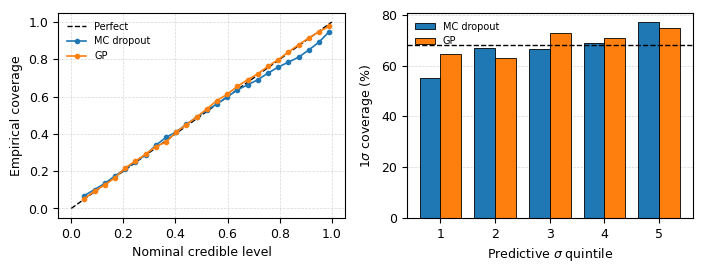

In [28]:
# Head-to-head: MC dropout vs GP, on accuracy and on calibration.
# Same held-out simulations, same normalisation, same metrics.

gp_cal = calibration_summary("GP", gp_pred_mean, gp_pred_std)
emulator_summaries = [mc_cal, gp_cal]

header = (
    f"{'model':<13}{'MAPE%':>8}{'RMS%':>8}{'1sig':>7}{'2sig':>7}{'3sig':>7}"
    f"{'rho_bin':>9}{'rho_sim':>9}{'ECE%':>7}"
)
print(header)
print("-" * len(header))
print(
    f"{'ideal':<13}{'-':>8}{'-':>8}{68.3:>7.1f}{95.4:>7.1f}{99.7:>7.1f}"
    f"{'high':>9}{'high':>9}{0.0:>7.1f}"
)
for s in emulator_summaries:
    print(
        f"{s['name']:<13}{s['mape']:>8.2f}{s['rms']:>8.2f}"
        f"{s['coverage'][0]:>7.1f}{s['coverage'][1]:>7.1f}{s['coverage'][2]:>7.1f}"
        f"{s['rho_bin']:>9.2f}{s['rho_sim']:>9.2f}{s['ece']:>7.1f}"
    )

print("\n1-sigma coverage by predictive-sigma quintile (ideal 68.3 everywhere):")
print(f"{'model':<13}" + "".join(f"{'Q' + str(i + 1):>8}" for i in range(5)))
for s in emulator_summaries:
    print(f"{s['name']:<13}" + "".join(f"{v:>8.1f}" for v in s["quintiles"]))

fig, ax = plt.subplots(1, 2, figsize=(7.1, 2.8))

colors = {"MC dropout": "tab:blue", "GP": "tab:orange"}

ax[0].plot([0, 1], [0, 1], "k--", linewidth=1.0, label="Perfect")
for s in emulator_summaries:
    ax[0].plot(
        s["nominal"], s["empirical"], marker="o", markersize=3, linewidth=1.2,
        color=colors[s["name"]], label=s["name"],
    )
ax[0].set_xlabel("Nominal credible level")
ax[0].set_ylabel("Empirical coverage")
ax[0].legend(frameon=False, fontsize=7)
ax[0].grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

width = 0.38
positions = np.arange(1, 6)
for k, s in enumerate(emulator_summaries):
    ax[1].bar(
        positions + (k - 0.5) * width, s["quintiles"], width,
        color=colors[s["name"]], edgecolor="black", linewidth=0.6, label=s["name"],
    )
ax[1].axhline(68.3, color="black", linestyle="--", linewidth=1.0)
ax[1].set_xlabel(r"Predictive $\sigma$ quintile")
ax[1].set_ylabel(r"$1\sigma$ coverage (%)")
ax[1].set_xticks(positions)
ax[1].legend(frameon=False, fontsize=7)
ax[1].set_axisbelow(True)
ax[1].grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
fig.savefig(
    FIG_DIR / f"gp_vs_mc_dropout_calibration_{EXPERIMENT_NAME}.pdf",
    format="pdf", bbox_inches="tight",
)
plt.show()


## Error Budget: Emulator vs Realization Scatter
Each parameter point was simulated once, so the held-out target is itself a
single noisy realization. This separates the two contributions.


REALIZATION SCATTER - two independent estimates
	A. GP WhiteKernel:			 5.73%   (upper bound)
	B. pair extrapolation to d=0:	 3.95%   (lower bound)

	per-bandpower GP noise sd: [7.15 5.67 5.33 5.18 5.07] %

ERROR BUDGET (fractional standard deviations)
	model / noise est.          total    noise  emulator   noise share
	------------------------------------------------------------------
	MC dropout / GP WhiteKernel    6.44%    5.73%     2.95%         79.1%
	MC dropout / pair extrap.    6.44%    3.95%     5.09%         37.6%
	GP / GP WhiteKernel         5.98%    5.73%     1.71%         91.8%
	GP / pair extrap.           5.98%    3.95%     4.49%         43.6%

Interpretation: the emulator cannot be scored below the realization
floor. A held-out MAPE at or near that floor means the metric is
measuring simulation noise, not emulator error.


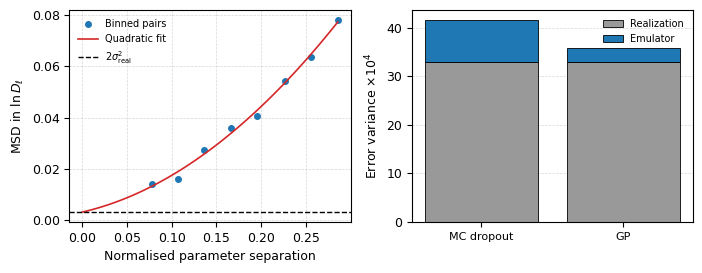

In [29]:
# Error budget: how much of the held-out error is the emulator, and how much is
# irreducible scatter in the simulations themselves?
#
# Each parameter point was run ONCE, so the "truth" the emulator is scored
# against is itself a single noisy realization of a stochastic field. Any error
# metric therefore contains both terms:
#
#     total^2  =  emulator^2  +  realization^2
#
# Two independent estimates of the realization term, deliberately both reported
# because they disagree and together they bracket the answer:
#
#   A. the GP's fitted WhiteKernel - a maximum-likelihood signal/noise split
#      across the whole training set. Upper bound: the white term also absorbs
#      any structure the Matern kernel cannot represent.
#   B. extrapolating the mean squared ln D_ell difference between simulation
#      PAIRS to zero parameter separation. As separation goes to zero the smooth
#      part cancels and only 2 x realization variance survives. Lower bound in
#      practice: 1000 points in 4D leaves the closest pairs still well separated,
#      so the extrapolation reaches a long way.
#
# Fractional and ln-space standard deviations are interchangeable at this level
# because ln(1 + f) ~ f for f of a few per cent.

from scipy.spatial import cKDTree

# ---- estimate A: GP white-noise term
s_noise_gp = np.sqrt(gp_noise_var.mean())

# ---- estimate B: pair-separation extrapolation
u_all = (X - PARAM_BOUNDS[:, 0]) / (PARAM_BOUNDS[:, 1] - PARAM_BOUNDS[:, 0])
pair_idx = cKDTree(u_all).query_pairs(r=0.30, output_type="ndarray")
pair_dist = np.linalg.norm(u_all[pair_idx[:, 0]] - u_all[pair_idx[:, 1]], axis=1)
pair_msd = np.mean((Y[pair_idx[:, 0]] - Y[pair_idx[:, 1]]) ** 2, axis=1)

bin_edges = np.linspace(0.0, 0.30, 11)
which_bin = np.digitize(pair_dist, bin_edges) - 1
bin_centre, bin_value, bin_count = [], [], []
for b in range(len(bin_edges) - 1):
    m = which_bin == b
    if m.sum() >= 30:
        bin_centre.append(pair_dist[m].mean())
        bin_value.append(pair_msd[m].mean())
        bin_count.append(int(m.sum()))
bin_centre = np.asarray(bin_centre)
bin_value = np.asarray(bin_value)

quad_fit = np.polyfit(bin_centre, bin_value, 2)
s_noise_pair = np.sqrt(max(quad_fit[-1], 0.0) / 2.0)

print("REALIZATION SCATTER - two independent estimates")
print(f"\tA. GP WhiteKernel:\t\t\t{s_noise_gp * 100:5.2f}%   (upper bound)")
print(f"\tB. pair extrapolation to d=0:\t{s_noise_pair * 100:5.2f}%   (lower bound)")
print(f"\n\tper-bandpower GP noise sd: "
      f"{np.array2string(np.sqrt(gp_noise_var) * 100, precision=2)} %")

print("\nERROR BUDGET (fractional standard deviations)")
head = f"\t{'model / noise est.':<24}{'total':>9}{'noise':>9}{'emulator':>10}{'noise share':>14}"
print(head)
print("\t" + "-" * (len(head) - 1))
for s in emulator_summaries:
    total = s["rms"] / 100.0
    for tag, s_noise in (("GP WhiteKernel", s_noise_gp), ("pair extrap.", s_noise_pair)):
        emu = np.sqrt(max(total**2 - s_noise**2, 0.0))
        share = 100.0 * s_noise**2 / total**2
        print(
            f"\t{s['name'] + ' / ' + tag:<24}"
            + f"{total * 100:>8.2f}%{s_noise * 100:>8.2f}%"
            f"{emu * 100:>9.2f}%{share:>13.1f}%"
        )

print("\nInterpretation: the emulator cannot be scored below the realization")
print("floor. A held-out MAPE at or near that floor means the metric is")
print("measuring simulation noise, not emulator error.")

fig, ax = plt.subplots(1, 2, figsize=(7.1, 2.8))

d_fine = np.linspace(0.0, bin_centre.max(), 100)
ax[0].plot(bin_centre, bin_value, "o", markersize=4, color="tab:blue", label="Binned pairs")
ax[0].plot(d_fine, np.polyval(quad_fit, d_fine), "-", color="tab:red",
           linewidth=1.2, label="Quadratic fit")
ax[0].axhline(quad_fit[-1], color="black", linestyle="--", linewidth=1.0,
              label=r"$2\sigma_{\rm real}^2$")
ax[0].set_xlabel("Normalised parameter separation")
ax[0].set_ylabel(r"MSD in $\ln D_\ell$")
ax[0].legend(frameon=False, fontsize=7)
ax[0].grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

names = [s["name"] for s in emulator_summaries]
totals = np.array([s["rms"] / 100.0 for s in emulator_summaries])
noise_part = np.minimum(s_noise_gp, totals)
emu_part = np.sqrt(np.maximum(totals**2 - noise_part**2, 0.0))
pos = np.arange(len(names))
ax[1].bar(pos, noise_part**2 * 1e4, color="0.6", edgecolor="black",
          linewidth=0.6, label="Realization")
ax[1].bar(pos, emu_part**2 * 1e4, bottom=noise_part**2 * 1e4, color="tab:blue",
          edgecolor="black", linewidth=0.6, label="Emulator")
ax[1].set_xticks(pos)
ax[1].set_xticklabels(names, fontsize=8)
ax[1].set_ylabel(r"Error variance $\times 10^{4}$")
ax[1].legend(frameon=False, fontsize=7)
ax[1].set_axisbelow(True)
ax[1].grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
fig.savefig(
    FIG_DIR / f"error_budget_{EXPERIMENT_NAME}.pdf", format="pdf", bbox_inches="tight"
)
plt.show()

## Best-Case Simulation

In [30]:
mean_error_per_sim = np.mean(absolute_relative_error, axis=1)

best_sim_testset_idx = np.argmin(mean_error_per_sim)
best_sim_global_idx = heldout_indices[best_sim_testset_idx]

print(f"Global Dataset Index: {best_sim_global_idx} \t Test-Set Index: {best_sim_testset_idx}")
print(f"Mean Absolute Relative Error: \t {(mean_error_per_sim[best_sim_testset_idx] * 100):.2f}%")

Global Dataset Index: 500 	 Test-Set Index: 120
Mean Absolute Relative Error: 	 0.42%


## Worst-Case Simulation

In [31]:
worst_sim_testset_idx = np.argmax(mean_error_per_sim)
worst_sim_global_idx = heldout_indices[worst_sim_testset_idx]

print(f"Global Dataset Index: {worst_sim_global_idx} \t Test-Set Index: {worst_sim_testset_idx}")
print(f"Mean Absolute Relative Error: \t {(mean_error_per_sim[worst_sim_testset_idx] * 100):.2f}%")

Global Dataset Index: 410 	 Test-Set Index: 105
Mean Absolute Relative Error: 	 17.66%


## Mean Percent Error Per Bin

Mean % Error Per ell Bin:
ell = 2033: 5.509%
ell = 4093: 4.931%
ell = 6153: 4.876%
ell = 8213: 4.984%
ell = 10273: 5.028%



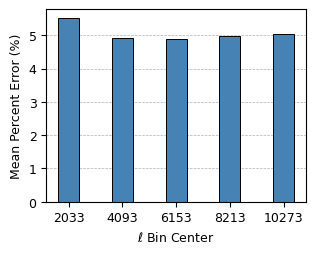

In [32]:
bin_percent_err = np.mean(absolute_relative_error, axis=0) * 100


print("Mean % Error Per ell Bin:")
ell_centers = np.asarray(ell).copy()
for ell_center, err in zip(ell_centers, bin_percent_err):
    print(f"ell = {ell_center:.0f}: {err:.3f}%")
print()

fig, ax = plt.subplots() 
ax.bar(
    ell_centers, 
    bin_percent_err, 
    width=800, 
    color='steelblue', 
    alpha=1, 
    edgecolor="black", 
    linewidth=0.7
)
ax.set_xlabel(r"$\ell$ Bin Center")
ax.set_xticks(ell_centers)
ax.set_xticklabels(ax.set_xticklabels([f"{e:.0f}" for e in ell_centers]))
ax.set_ylabel("Mean Percent Error (%)")
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=1)
fig.savefig(FIG_DIR / f'mean_percent_error_per_ell_{EXPERIMENT_NAME}.pdf', format='pdf', bbox_inches="tight")
plt.show()

## True vs Predicted Rescaled kSZ Angular Power Spectrum

In [33]:
BEST_SIM = best_sim_global_idx
WORST_SIM = worst_sim_global_idx

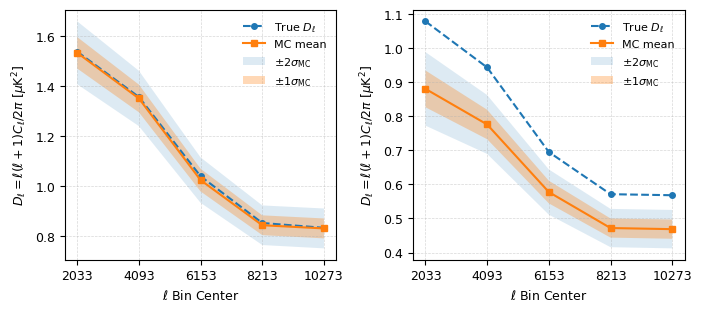

In [34]:
def plot_best_and_worst(best_idx, worst_idx):
    fig, ax = plt.subplots(1, 2, figsize=(7.1, 3.2))

    sim_indices = [best_idx, worst_idx]

    for i, sim_idx in enumerate(sim_indices):
        # Fetch data for this specific simulation
        params = X[sim_idx]
        true_dl = np.exp(Y[sim_idx])
        pred_dl, pred_std, samples_dl, samples_log = predict_mc(
            params,
            model,
            norms["X"].mean,
            norms["X"].std,
            normalize_X=True,
            n_mc_samples=N_MC_PLOT,
        )

        # Plot True Data
        ax[i].plot(
            ell,
            true_dl,
            marker="o",
            linestyle="--",
            markersize=4,
            label=r"True $D_\ell$",
        )

        # Plot MC Mean
        ax[i].plot(
            ell,
            pred_dl,
            marker="s",
            linestyle="-",
            markersize=4,
            label=r"MC mean",
        )

        # Plot 2-Sigma Fill
        ax[i].fill_between(
            ell,
            pred_dl - 2.0 * pred_std,
            pred_dl + 2.0 * pred_std,
            alpha=0.15,
            label=r"$\pm 2\sigma_{\rm MC}$",
        )

        # Plot 1-Sigma Fill
        ax[i].fill_between(
            ell,
            pred_dl - pred_std,
            pred_dl + pred_std,
            alpha=0.30,
            label=r"$\pm 1\sigma_{\rm MC}$",
        )

        ax[i].set_xlabel(r"$\ell$ Bin Center")
        ax[i].grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
        ax[i].legend(frameon=False, fontsize=8)

    ax[0].set_ylabel(r"$D_\ell = \ell(\ell + 1)C_\ell / 2\pi$ [$\mu \mathrm{K}^2$]")
    ax[1].set_ylabel(r"$D_\ell = \ell(\ell + 1)C_\ell / 2\pi$ [$\mu \mathrm{K}^2$]")

    ax[0].set_xticks(ell_centers)
    ax[0].set_xticklabels([f"{e:.0f}" for e in ell_centers])
    
    ax[1].set_xticks(ell_centers)
    ax[1].set_xticklabels([f"{e:.0f}" for e in ell_centers])

    plt.tight_layout()

    fig.savefig(FIG_DIR / f"mc_dropout_best_worst_{EXPERIMENT_NAME}.pdf", format="pdf", bbox_inches="tight")
    plt.show()


plot_best_and_worst(BEST_SIM, WORST_SIM)

## One-to-One Plot

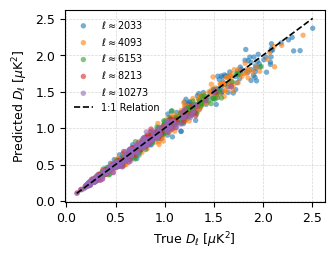

(200, 5) (200, 5)


In [35]:
# Standard single-column width, square aspect ratio
fig, ax = plt.subplots()

for b, ell_center in enumerate(ell):
    ax.scatter(
        true[:, b],
        pred_mean[:, b],
        s=15,
        alpha=0.6,
        edgecolors='none',
        label=rf"$\ell \approx {ell_center:.0f}$",
        zorder=2
    )

min_val = min(true.min(), pred_mean.min())
max_val = max(true.max(), pred_mean.max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color="black",
    linewidth=1.2,
    label="1:1 Relation",
    zorder=3
)

ax.set_xlabel(r"True $D_\ell$ [$\mu \mathrm{K}^2$]")
ax.set_ylabel(r"Predicted $D_\ell$ [$\mu \mathrm{K}^2$]")

ax.set_axisbelow(True)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

ax.legend(frameon=False, fontsize=7)

# Save and display
fig.savefig(FIG_DIR / f"true_vs_predicted_all_bins_{EXPERIMENT_NAME}.pdf", format="pdf", bbox_inches="tight")
plt.show()

print(true.shape, pred_mean.shape)

## Violin Plots of True vs Predicted Distributions

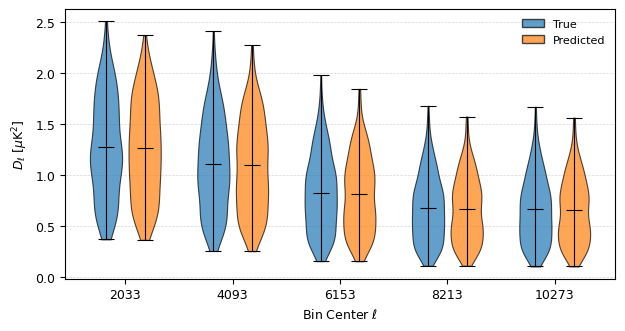

In [36]:
fig, ax = plt.subplots(figsize=(7.1, 3.5))

positions = np.arange(len(ell_centers))
offset = 0.18

true_parts = ax.violinplot(
    [true[:, b] for b in range(len(ell_centers))],
    positions=positions - offset,
    widths=0.3,
    showmeans=True,
    showextrema=True,
)

pred_parts = ax.violinplot(
    [pred_mean[:, b] for b in range(len(ell_centers))],
    positions=positions + offset,
    widths=0.3,
    showmeans=True,
    showextrema=True,
)

# Softened alpha to 0.7 so the data breathes
for pc in true_parts['bodies']:
    pc.set_facecolor('tab:blue')
    pc.set_edgecolor('black')
    pc.set_alpha(0.7) 
    pc.set_linewidth(0.8)

for partname in ('cbars', 'cmins', 'cmaxes', 'cmeans'):
    true_parts[partname].set_edgecolor('black')
    true_parts[partname].set_linewidth(0.8)

for pc in pred_parts['bodies']:
    pc.set_facecolor('tab:orange')
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)
    pc.set_linewidth(0.8)

for partname in ('cbars', 'cmins', 'cmaxes', 'cmeans'):
    pred_parts[partname].set_edgecolor('black')
    pred_parts[partname].set_linewidth(0.8)

ax.set_xticks(positions)
ax.set_xticklabels([f"{e:.0f}" for e in ell_centers])
ax.set_xlabel(r"Bin Center $\ell$")
ax.set_ylabel(r"$D_\ell$ [$\mu \mathrm{K}^2$]")

ax.set_axisbelow(True)
# Softened the grid alpha back to 0.5
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)

# Match the legend alpha to the bodies
true_patch = mpatches.Patch(facecolor='tab:blue', edgecolor='black', alpha=0.7, label='True')
pred_patch = mpatches.Patch(facecolor='tab:orange', edgecolor='black', alpha=0.7, label='Predicted')
ax.legend(handles=[true_patch, pred_patch], frameon=False, fontsize=8)

fig.savefig(FIG_DIR / f"true_predicted_violin_by_bin_{EXPERIMENT_NAME}.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Many Held-Out Spectra Plot

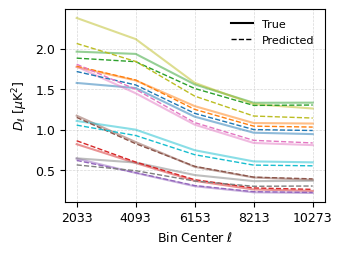

In [37]:
fig, ax = plt.subplots()

n_show = 10
rng = np.random.default_rng(42)
idx = rng.choice(true.shape[0], size=n_show, replace=False)

for i in idx:
    true_line, = ax.plot(
        ell_centers,
        true[i],
        alpha=0.5,
        linewidth=1.5,
    )

    ax.plot(
        ell_centers,
        pred_mean[i],
        color=true_line.get_color(),
        alpha=1.0,
        linewidth=1.0,
        linestyle="--",
        zorder=3
    )

ax.plot([], [], color='black', alpha=1.0, linewidth=1.5, label="True")
ax.plot([], [], color='black', alpha=1.0, linewidth=1.0, linestyle="--", label="Predicted")

ax.set_xlabel(r"Bin Center $\ell$")
ax.set_xticks(ell_centers)
ax.set_xticklabels(ax.set_xticklabels([f"{e:.0f}" for e in ell_centers]))
ax.set_ylabel(r"$D_\ell$ [$\mu \mathrm{K}^2$]")

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax.legend(frameon=False, fontsize=8)

fig.savefig(FIG_DIR / f"many_heldout_true_predicted_spectra_{EXPERIMENT_NAME}.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Stability Plot

In [38]:
N_PILOT = 1000
TOL_MEAN, TOL_STD = 0.01, 0.05

_, _, samples_dl, _ = predict_mc(
    X[best_sim_global_idx], model,
    norms["X"].mean, norms["X"].std,
    normalize_X=True, n_mc_samples=N_PILOT,
)

cv = samples_dl.std(axis=0, ddof=1) / samples_dl.mean(axis=0)

n_mean = int(np.ceil((cv.max() / TOL_MEAN) ** 2))
n_std  = int(np.ceil(1 + 1 / (2 * TOL_STD ** 2)))

print(f"Per-bin CV: \t {np.round(cv, 3)}")
print(f"N for mean at {TOL_MEAN:.0%}: {n_mean}")
print(f"N for std  at {TOL_STD:.0%}: {n_std}")
print(f"N_MC = {max(n_mean, n_std)}")

Per-bin CV: 	 [0.038 0.038 0.041 0.043 0.044]
N for mean at 1%: 20
N for std  at 5%: 201
N_MC = 201


# Parameter Inference - Markov-Chain Monte Carlo
---
- The MC-dropout emulator cannot reliably extrapolate outside the parameterspace. Therefore, the optimal sample should be near the middle.
- To find the sample closest to the middle, we apply a transformation so the parameters are measured on a common scale
$$ u = \frac{(x -lo)}{(hi - lo)}$$
Then, we measure the distance each parameter is from the center of their bound:
$$d = \sqrt((u_1 - 0.5)^2 + (u_2 - 0.5)^2 + (u_3 - 0.5)^2 + (u_4 - 0.5)^2)$$

In [39]:
X, Y, ell = load_training_arrays(H5_PATH)
# Grab the indices for the test dataset
heldout_indices = np.asarray(loaders["test"].dataset.indices, dtype=int)
# Separate test indices from the rest
X_heldout = X[heldout_indices]
Y_heldout = Y[heldout_indices]

# PARAM_BOUNDS and param_labels are defined once in the configuration cell at
# the top of the notebook.

u = (X_heldout - PARAM_BOUNDS[:, 0]) / (PARAM_BOUNDS[:, 1] - PARAM_BOUNDS[:, 0])
dist = np.linalg.norm(u - 0.5, axis=1)

# Named `central_order`, not `order`: `order` is used as a throwaway loop
# variable in later cells, and reusing it here silently selected the wrong
# simulations in the batch-MCMC cell further down.
central_order = np.argsort(dist)
smallest_dist = central_order[0]
print("Simulation with the Smallest Distance to the Center")
print(f"Test-Set Index: {smallest_dist} \t Global Dataset Index: {heldout_indices[smallest_dist]}")
print()
print("Top 5 Simulations with Smallest Distance to the Center")
for pos in central_order[:5]:
    print(f"\tTest-Set Index: {pos} \t Global Dataset Index: {heldout_indices[pos]} \n\t\tDist {dist[pos]:.3f} \t X {X_heldout[pos]}")

Simulation with the Smallest Distance to the Center
Test-Set Index: 37 	 Global Dataset Index: 106

Top 5 Simulations with Smallest Distance to the Center
	Test-Set Index: 37 	 Global Dataset Index: 106 
		Dist 0.174 	 X [7.7922134  0.47120032 1.299202   0.47073376]
	Test-Set Index: 11 	 Global Dataset Index: 32 
		Dist 0.197 	 X [7.895161   0.38562214 0.9680844  0.36761492]
	Test-Set Index: 30 	 Global Dataset Index: 450 
		Dist 0.208 	 X [8.279356   0.54046345 1.2756785  0.39021048]
	Test-Set Index: 0 	 Global Dataset Index: 560 
		Dist 0.226 	 X [8.035813  0.4903779 0.6846715 0.5314246]
	Test-Set Index: 90 	 Global Dataset Index: 111 
		Dist 0.238 	 X [7.940788   0.6186654  1.3747473  0.40292513]


In [40]:
def log_prior(theta):
    # Flat prior over PARAM_BOUNDS; -inf outside acts as a hard wall.
    theta = np.asarray(theta)

    if np.any(theta < PARAM_BOUNDS[:, 0]) or np.any(theta > PARAM_BOUNDS[:, 1]):
        return -np.inf

    return 0.0

def predict_emulator(theta):
    theta = np.array(theta, dtype=np.float32)

    pred_dl, pred_std, _, _ = predict_mc(
        theta,
        model,
        norms["X"].mean,
        norms["X"].std,
        normalize_X=True,
        n_mc_samples=100,
    )

    return pred_dl, pred_std


def log_likelihood(theta, observed_dl, sigma_obs):
    model_dl, emulator_std = predict_emulator(theta)

    sigma_total = np.sqrt(sigma_obs**2 + emulator_std**2)

    residual = observed_dl - model_dl

    chi2 = np.sum((residual / sigma_total) ** 2)
    log_det = np.sum(np.log(2.0 * np.pi * sigma_total**2))

    return -0.5 * (chi2 + log_det)


def log_probability(theta, observed_dl, sigma_obs):
    lp = log_prior(theta)

    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood(theta, observed_dl, sigma_obs)

In [41]:
%%time

# The mock observation is defined whether or not the chain is re-run, because
# every downstream cell needs true_params / observed_dl / sigma_obs.
TEST_SET_IDX = smallest_dist

true_params = X_heldout[TEST_SET_IDX]
observed_dl = np.exp(Y_heldout[TEST_SET_IDX])
sigma_obs = 0.10 * observed_dl

# MCMC setup
ndim = 4
nwalkers = 32
nsteps = 30_000

if RUN_SINGLE_MCMC:
    # emcee inherits the global NumPy RNG state at construction, and the MC-dropout
    # likelihood draws from torch's RNG, so seed both to make this chain reproducible.
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    initial_pos = true_params + 1e-2 * np.random.randn(nwalkers, ndim)

    for j, (low, high) in enumerate(PARAM_BOUNDS):
        initial_pos[:, j] = np.clip(initial_pos[:, j], low, high)

    sampler = emcee.EnsembleSampler(
        nwalkers,
        ndim,
        log_probability,
        args=(observed_dl, sigma_obs),
    )

    sampler.run_mcmc(initial_pos, nsteps, progress=True)
else:
    print("RUN_SINGLE_MCMC = False: skipping the chain. The MCMC diagnostics,")
    print("corner plot, posterior predictive and physical-validation cells below")
    print("all need this chain and will not run.")

100%|██████████| 30000/30000 [19:36<00:00, 25.50it/s]

CPU times: user 19min 5s, sys: 8.83 s, total: 19min 14s
Wall time: 19min 36s


## Likelihood Noise Check
---
- `predict_mc` redraws dropout masks on every call, so `log_probability` is stochastic: the same $\theta$ returns a different value each time.
- emcee carries an accepted point's log-probability forward, which gives this a pseudo-marginal character, but the estimator is not unbiased in likelihood space, so a noisy likelihood can inflate the posterior and lengthen the autocorrelation time.
- Scatter well below ~0.5 is negligible; approaching ~1 or more means `n_mc_samples` in `predict_emulator` should be raised.

In [42]:
# Repeated evaluations at a fixed theta isolate the MC-dropout noise in the likelihood.
n_repeat = 200
logp_repeat = np.array([
    log_probability(true_params, observed_dl, sigma_obs) for _ in range(n_repeat)
])

print(f"log-probability at fixed theta over {n_repeat} evaluations:")
print(f"\tmean = {logp_repeat.mean():.3f}")
print(f"\tstd  = {logp_repeat.std(ddof=1):.3f}")
print(f"\trange = [{logp_repeat.min():.3f}, {logp_repeat.max():.3f}]")

if logp_repeat.std(ddof=1) < 0.5:
    print("\nScatter is small: the stochastic likelihood should not measurably bias the posterior.")
else:
    print("\nScatter is large enough to broaden the posterior and lengthen the "
          "autocorrelation time; consider raising n_mc_samples in predict_emulator.")

log-probability at fixed theta over 200 evaluations:
	mean = 6.046
	std  = 0.049
	range = [5.894, 6.144]

Scatter is small: the stochastic likelihood should not measurably bias the posterior.


## Diagnose Chain

In [43]:
# Integrated autocorrelation time drives burn-in and thinning.
# tol=0 returns the estimate instead of raising when the chain is short.
tau_autocorr = sampler.get_autocorr_time(tol=0)
tau_max = float(np.max(tau_autocorr))
n_per_walker = sampler.get_chain().shape[0]

print("Autocorrelation time per parameter:", tau_autocorr)
print(f"N / tau = {n_per_walker / tau_max:.0f}\t(want > 50)")

# Single source of truth: every downstream cell (metrics, corner plot, posterior
# predictive, physical validation) uses this `samples` array.
MCMC_DISCARD = int(5 * tau_max)
MCMC_THIN = max(1, int(0.5 * tau_max))
samples = sampler.get_chain(discard=MCMC_DISCARD, thin=MCMC_THIN, flat=True)

print(f"discard={MCMC_DISCARD}, thin={MCMC_THIN}, posterior samples={samples.shape[0]}")

Autocorrelation time per parameter: [114.31883438 106.54139731 126.64113099 127.63009295]
N / tau = 235	(want > 50)
discard=638, thin=63, posterior samples=14912


## Metrics

In [44]:
print("Posterior median with 68% credible interval:")
for i, label in enumerate(param_labels):
    q16, q50, q84 = np.percentile(samples[:, i], [16, 50, 84])
    print(rf"{label}: {q50:.3f} + {q84 - q50:.3f} - {q50 - q16:.3f}")

print("\nTrue parameters:")
print(true_params)

print("\nMean acceptance fraction:", np.mean(sampler.acceptance_fraction))
print("Acceptance fractions:", sampler.acceptance_fraction)

Posterior median with 68% credible interval:
$\bar{z}$: 7.835 + 0.718 - 0.597
$\alpha$: 0.408 + 0.287 - 0.208
$k_b$: 1.289 + 0.488 - 0.665
$b_0$: 0.478 + 0.095 - 0.079

True parameters:
[7.7922134  0.47120032 1.299202   0.47073376]

Mean acceptance fraction: 0.41418645833333334
Acceptance fractions: [0.42426667 0.4125     0.41676667 0.41146667 0.4133     0.41803333
 0.4099     0.416      0.417      0.4072     0.41913333 0.42126667
 0.41093333 0.41276667 0.4079     0.42783333 0.41243333 0.41703333
 0.41093333 0.40953333 0.42106667 0.41136667 0.4122     0.414
 0.4198     0.40333333 0.4145     0.41156667 0.41046667 0.40813333
 0.4156     0.41573333]


## Corner Plot

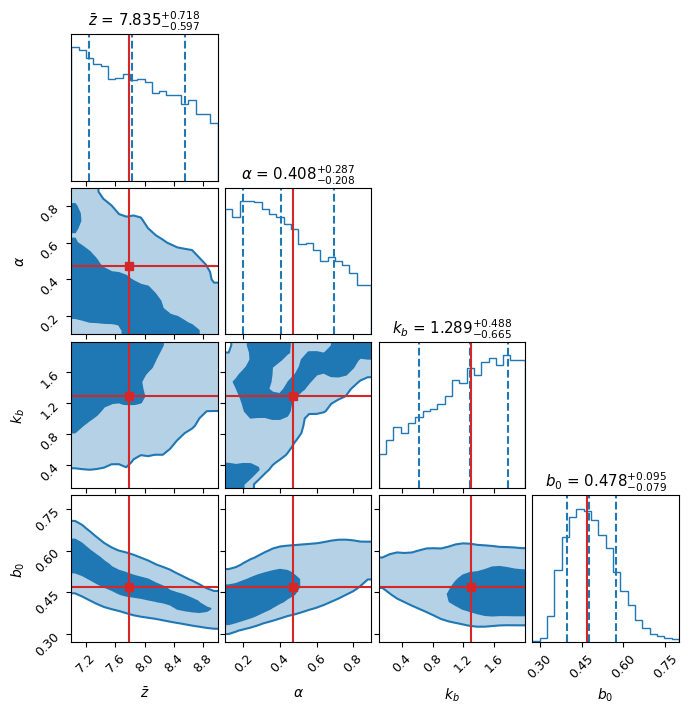

In [45]:
samples_for_corner = samples

fig = plt.figure(figsize=(7.1, 7.1))

fig = corner.corner(
    samples_for_corner,
    fig=fig,
    labels=param_labels,
    truths=true_params,
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84],
    plot_datapoints=False,
    fill_contours=True,
    smooth=1.0,

    levels=(1 - np.exp(-0.5), 1 - np.exp(-2.0)), 

    truth_color="tab:red",               
    color="tab:blue",                    
    label_kwargs={"fontsize": 10},
)

plt.savefig(
    FIG_DIR / f"emulator_based_MCMC_posterior_{EXPERIMENT_NAME}.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

## Posterior Predictive $D_\ell$ Spectrum

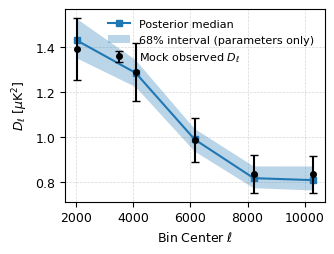

In [46]:
rng = np.random.default_rng(42)
n_draws = 200
draw_indices = rng.choice(len(samples), size=n_draws, replace=False)
theta_draws = samples[draw_indices]

posterior_preds = []
for theta in theta_draws:
    # Bound to loop-local names: `pred_mean` / `pred_std` above hold the held-out
    # test-set predictions that the artifact save still needs.
    draw_dl, _draw_std = predict_emulator(theta)
    posterior_preds.append(draw_dl)

posterior_preds = np.asarray(posterior_preds)

pred_16, pred_50, pred_84 = np.percentile(
    posterior_preds,
    [16, 50, 84],
    axis=0,
)


fig, ax = plt.subplots()

ax.errorbar(
    ell,
    observed_dl,
    yerr=sigma_obs,
    marker="o",
    color="black",         
    markersize=4,
    capsize=3,
    linestyle="none",
    label=r"Mock observed $D_\ell$",
    zorder=4
)

ax.plot(
    ell,
    pred_50,
    marker="s",
    markersize=4,
    color="tab:blue",
    label=r"Posterior median",
    zorder=3
)

ax.fill_between(
    ell,
    pred_16,
    pred_84,
    color="tab:blue",
    alpha=0.3,
    edgecolor="none",
    label=r"68% interval (parameters only)",
    zorder=2
)

ax.set_xlabel(r"Bin Center $\ell$")
ax.set_ylabel(r"$D_\ell$ [$\mu \mathrm{K}^2$]")

ax.set_axisbelow(True)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax.legend(frameon=False, fontsize=8)

plt.savefig(FIG_DIR / f"posterior_predictive_kSZ_power_spectrum_{EXPERIMENT_NAME}.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Residual or Percent-Error Posterior Predictive Plot

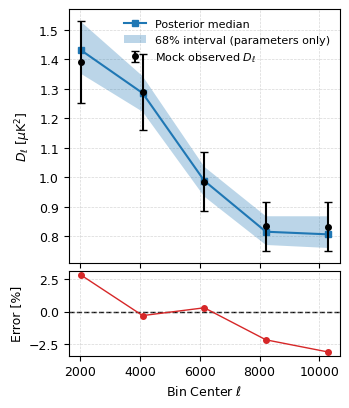

In [47]:
pct_error = 100.0 * (pred_50 - observed_dl) / observed_dl

fig, (ax_main, ax_res) = plt.subplots(
    nrows=2, 
    ncols=1, 
    figsize=(3.5, 4.5),
    sharex=True, 
    gridspec_kw={'height_ratios': [3, 1]}
)

ax_main.errorbar(ell, observed_dl, yerr=sigma_obs, marker="o", color="black", markersize=4, capsize=3, linestyle="none", label=r"Mock observed $D_\ell$", zorder=4)
ax_main.plot(ell, pred_50, marker="s", markersize=4, color="tab:blue", label=r"Posterior median", zorder=3)
ax_main.fill_between(ell, pred_16, pred_84, color="tab:blue", label=r"68% interval (parameters only)", alpha=0.3, edgecolor="none", zorder=2)

ax_main.set_ylabel(r"$D_\ell$ [$\mu \mathrm{K}^2$]")
ax_main.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax_main.legend(frameon=False, fontsize=8)


ax_res.axhline(0.0, color="black", linestyle="--", linewidth=1.0, zorder=1)

ax_res.plot(ell, pct_error, marker="o", markersize=4, color="tab:red", linewidth=1.0, zorder=2)

ax_res.set_xlabel(r"Bin Center $\ell$")
ax_res.set_ylabel("Error [%]")
ax_res.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

plt.subplots_adjust(hspace=0.05)

plt.savefig(FIG_DIR / f"posterior_predictive_with_residuals_{EXPERIMENT_NAME}.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Trace Plot

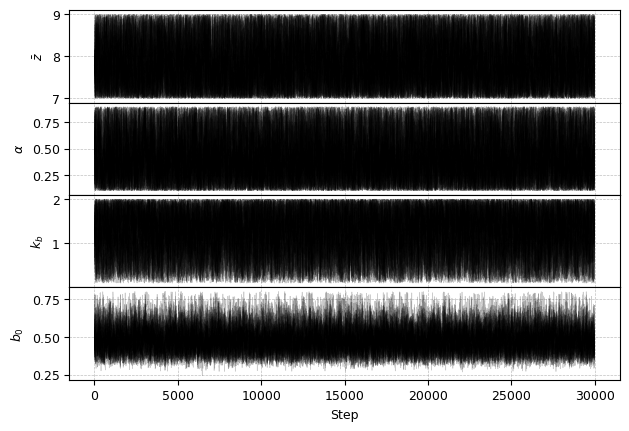

In [48]:
chain = sampler.get_chain()

fig, axes = plt.subplots(ndim, figsize=(7.1, 4.8), sharex=True)

if ndim == 1:
    axes = [axes]

for i in range(ndim):
    axes[i].plot(chain[:, :, i], color="black", alpha=0.2, linewidth=0.5)
    
    axes[i].set_ylabel(param_labels[i])
    
    axes[i].set_axisbelow(True)
    axes[i].grid(True, linestyle='--', linewidth=0.5, alpha=0.8)

axes[-1].set_xlabel("Step")

plt.subplots_adjust(hspace=0.0)

plt.savefig(FIG_DIR / f"trace_plot_{EXPERIMENT_NAME}.pdf", format="pdf", bbox_inches="tight")
plt.show()

# MCMC Physical Validation
---
- Mean of the posterior distribution and find the mean.
- [Wikipedia Inverse Distance Weighting](https://en.wikipedia.org/wiki/Inverse_distance_weighting)
- [Scipy LinearNDInterpolator](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.LinearNDInterpolator.html#scipy.interpolate.LinearNDInterpolator)
- Start with Tau and then the full ionization histories. For true and MCMC values.

## Held-Out Mock Observation
- True Parameters: The _zreion_ parameters MCMC was trying to recover.
- Observed $D_\ell$: The 5 binned kSZ rescaled angular power spectrum that is the "observed" data.
- Sigma OBS: The assumed measurement uncertainty.

In [49]:
print("TEST_SET_IDX:\t", TEST_SET_IDX)
print("True Parameters:", true_params)
print("Observed D_ell:\t", observed_dl)
print("Sigma OBS:\t\t", sigma_obs)

TEST_SET_IDX:	 37
True Parameters: [7.7922134  0.47120032 1.299202   0.47073376]
Observed D_ell:	 [1.391342   1.2893534  0.9857267  0.8343168  0.83325124]
Sigma OBS:		 [0.13913421 0.12893534 0.09857267 0.08343168 0.08332513]


## Parameter Recovery Table
- Summary of the marginal posterior distributions from the MCMC. For each parameter: the true value, the posterior mean, the posterior median with its 68% credible interval (16th–84th percentiles), and the bias (posterior mean − true).

In [50]:
header = f"{'Parameter':<12}{'True':>12}{'Post. Mean':>14}{'Post. Median (16/84)':>28}{'Mean - True':>14}"
print(header)
print("-" * len(header))
for i, label in enumerate(param_labels):
    q16, q50, q84 = np.percentile(samples[:, i], [16, 50, 84])
    mean_i = samples[:, i].mean()
    true_i = true_params[i]
    median_str = f"{q50:.3f} +{q84 - q50:.3f} -{q50 - q16:.3f}"
    print(f"{label:<12}{true_i:>12.3f}{mean_i:>14.3f}{median_str:>28}{mean_i - true_i:>14.3f}")

Parameter           True    Post. Mean        Post. Median (16/84)   Mean - True
--------------------------------------------------------------------------------
$\bar{z}$          7.792         7.879         7.835 +0.718 -0.597         0.087
$\alpha$           0.471         0.436         0.408 +0.287 -0.208        -0.035
$k_b$              1.299         1.224         1.289 +0.488 -0.665        -0.075
$b_0$              0.471         0.486         0.478 +0.095 -0.079         0.016


## Interpolation Utilities
- Defines the parameter bounds, unit-hypercube normalization, and the IDW (Shepard's method)
interpolator used to map MCMC posterior samples to physical quantities ($\tau$, $x_e(z)$)
by interpolating over the existing simulation suite.

In [51]:
# PARAM_BOUNDS is defined once in the MCMC section and reused here.

def normalize_params(X):
    """
    Min-max scaling: u = (x-lo)/(hi-lo)
    """
    X = np.asarray(X)
    return (X - PARAM_BOUNDS[:, 0]) / (PARAM_BOUNDS[:, 1] - PARAM_BOUNDS[:, 0])


def idw_predict(X_train, y_train, X_query, k=32, power=2, eps=1e-12):
    """
    Inverse distance weighting (Shepards method).
    X_train: (N, D)
    y_train: (N,) or (N, M)
    X_query: (Q, D)
    """
    # Build a k-d tree for fast nearest-neighbor lookup
    tree = cKDTree(X_train)
    # Find k nearest training points
    distances, indices = tree.query(X_query, k=k)

    # SciPy returns (Q,) when k=1; restore 2D shape (Q, 1)
    if k == 1:
        distances = distances[:, None]
        indices = indices[:, None]

    # Inverse-distance weights, normalized to sum to 1 per query
    weights = 1.0 / (distances + eps) ** power
    weights = weights / weights.sum(axis=1, keepdims=True)

    y_neighbors = y_train[indices]

    if y_train.ndim == 1:
        return np.sum(weights * y_neighbors, axis=1)

    return np.sum(weights[:, :, None] * y_neighbors, axis=1)

## Build Lookup Table

In [52]:
param_order = ["zmean_zre", "alpha_zre", "kb_zre", "b0_zre"]

X_rows = []
tau_rows = []
xe_rows = []
z_grid = None

with h5py.File(H5_PATH, "r") as h5f:
    sims = h5f["sims"]

    sim_names = sorted(
        sims.keys(),
        key=lambda s: int(s[3:]) if s.startswith("sim") and s[3:].isdigit() else s,
    )

    for sim in sim_names:
        g = sims[sim]

        # Parameters, in the same order as your emulator/MCMC
        theta = [
            float(g[f"params/{p}"][()])
            for p in param_order
        ]

        # Tau
        tau = float(g["output/tau"][()])

        # Ionization history
        z_sim = np.array(g["output/zval_list"][()], dtype=float)
        xe = np.array(g["output/xmval_list"][()], dtype=float)

        # Sort by redshift so plotting/interpolation is clean
        z_order = np.argsort(z_sim)
        z_sim = z_sim[z_order]
        xe = xe[z_order]

        # Use the first simulation's z grid as the reference grid
        if z_grid is None:
            z_grid = z_sim
        else:
            # If another simulation has the same grid, use directly.
            # If not, interpolate its history onto the reference grid.
            if len(z_sim) != len(z_grid) or not np.allclose(z_sim, z_grid):
                xe = np.interp(z_grid, z_sim, xe)

        X_rows.append(theta)
        tau_rows.append(tau)
        xe_rows.append(xe)

X_sim = np.array(X_rows, dtype=float)
tau_sim = np.array(tau_rows, dtype=float)
xe_sim = np.array(xe_rows, dtype=float)

print("X_sim shape:", X_sim.shape)
print("tau_sim shape:", tau_sim.shape)
print("xe_sim shape:", xe_sim.shape)
print("z_grid shape:", z_grid.shape)

assert X_sim.shape[1] == 4
assert tau_sim.shape[0] == X_sim.shape[0]
assert xe_sim.shape[0] == X_sim.shape[0]
assert xe_sim.shape[1] == len(z_grid)

X_sim shape: (1000, 4)
tau_sim shape: (1000,)
xe_sim shape: (1000, 26)
z_grid shape: (26,)


## Normalize

In [53]:
# Normalize full simulation design points
Xn = normalize_params(X_sim)

# Normalize MCMC posterior samples
samples_n = normalize_params(samples)

# Normalize true parameters
true_n = normalize_params(true_params[None, :])

# Posterior summary parameters
posterior_mean = samples.mean(axis=0)
posterior_median = np.median(samples, axis=0)

posterior_p16 = np.percentile(samples, 16, axis=0)
posterior_p84 = np.percentile(samples, 84, axis=0)

# Normalize posterior mean and median
posterior_mean_n = normalize_params(posterior_mean[None, :])
posterior_median_n = normalize_params(posterior_median[None, :])

print("Posterior mean:\t ", posterior_mean)
print("Posterior median:", posterior_median)
print("Posterior 16th percentile:", posterior_p16)
print("Posterior 84th percentile:", posterior_p84)

Posterior mean:	  [7.87903836 0.43637404 1.22405976 0.48634793]
Posterior median: [7.8347434  0.40849881 1.28941032 0.47754488]
Posterior 16th percentile: [7.23748272 0.20043238 0.62460796 0.39835203]
Posterior 84th percentile: [8.55315306 0.69545896 1.77766241 0.57302609]


## Method 1: LinearNDInterpolator for Tau
- Piecewise-linear interpolation of $\tau$ over a Delaunay triangulation of the normalized design points; exact at the design points themselves.
- Returns NaN for posterior samples outside the convex hull of the simulations — the printed NaN fraction measures how much of the $\tau$ posterior relies on unvalidated extrapolation.
- Serves as the cross-check: agreement with IDW shows the $\tau$ posterior is insensitive to the choice of interpolation method.

In [54]:
tau_linear_interp = LinearNDInterpolator(Xn, tau_sim, fill_value=np.nan)

tau_true_interp = tau_linear_interp(true_n)[0]
tau_mean_interp = tau_linear_interp(posterior_mean_n)[0]
tau_posterior_linear = tau_linear_interp(samples_n)

print("LinearND Tau at True Params:", tau_true_interp)
print("LinearND Tau at Posterior Mean:", tau_mean_interp)

# Convex-hull coverage: LinearND returns NaN outside the convex hull of the
# 1000 simulation points.
nan_frac = np.isnan(tau_posterior_linear).mean()
print(f"\nPosterior samples outside convex hull (LinearND NaN): "
      f"{nan_frac * 100:.2f}% ({np.isnan(tau_posterior_linear).sum()} / {len(tau_posterior_linear)})")
if nan_frac > 0.0:
    print("IDW extrapolates over these samples; treat the IDW tau tails with caution.")

LinearND Tau at True Params: 0.058188996588756474
LinearND Tau at Posterior Mean: 0.059165552713505806

Posterior samples outside convex hull (LinearND NaN): 9.72% (1449 / 14912)
IDW extrapolates over these samples; treat the IDW tau tails with caution.


## Method 2: IDW for Tau
- Inverse-distance-weighted $\tau$ from the $k = 32$ nearest simulations; defined for every posterior sample, including those outside the convex hull.
- Provides the working $\tau$ posterior used for the credible intervals, summary statistics, and figures, since it has no missing (NaN) samples.

In [55]:
tau_true_idw = idw_predict(Xn, tau_sim, true_n)[0]
tau_mean_idw = idw_predict(Xn, tau_sim, posterior_mean_n)[0]
tau_posterior_idw = idw_predict(Xn, tau_sim, samples_n)

print("IDW tau at true params:\t\t", tau_true_idw)
print("IDW tau at posterior mean:\t", tau_mean_idw)

IDW tau at true params:		 0.058188995270356994
IDW tau at posterior mean:	 0.058811404077873414


## Summary Function

In [56]:
def summarize(values):
    values = np.asarray(values)
    values = values[np.isfinite(values)]

    return {
        "mean": np.mean(values),
        "median": np.median(values),
        "p16": np.percentile(values, 16),
        "p84": np.percentile(values, 84),
        "p2.5": np.percentile(values, 2.5),
        "p97.5": np.percentile(values, 97.5),
    }

tau_summary = summarize(tau_posterior_idw)
print("Tau posterior summary:")
print(tau_summary)

Tau posterior summary:
{'mean': np.float64(0.059316549914666936), 'median': np.float64(0.05873785586374769), 'p16': np.float64(0.05426292794418201), 'p84': np.float64(0.06506840524645288), 'p2.5': np.float64(0.05323799214794152), 'p97.5': np.float64(0.0673817954676154)}


## Tau Posterior

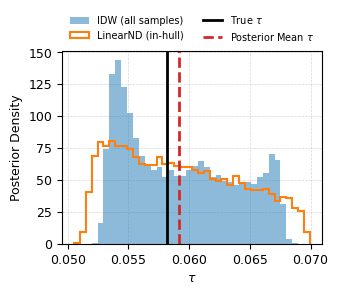

True Tau 				 = 0.0582
Posterior Mean Tau 		 = 0.0593
Posterior 68% Interval 	 = [0.0543, 0.0651]
Posterior 95% Interval 	 = [0.0532, 0.0674]

True Tau Inside 68% Interval: True
True Tau Inside 95% Interval: True
The MCMC posterior recovers the correct optical depth tau (true value within the 68% credible interval).


In [57]:
fig, ax = plt.subplots()

# Overlay both interpolation methods. IDW covers all samples (it extrapolates);
# LinearND is NaN outside the convex hull, so its histogram only reflects
# in-hull samples. Agreement between the two validates the interpolation.
tau_linear_valid = tau_posterior_linear[np.isfinite(tau_posterior_linear)]

bin_edges = np.histogram_bin_edges(
    np.concatenate([tau_posterior_idw, tau_linear_valid]), bins=40
)

ax.hist(tau_posterior_idw, bins=bin_edges, alpha=0.5, density=True, color="tab:blue", label="IDW (all samples)")
ax.hist(tau_linear_valid, bins=bin_edges, density=True, histtype="step", linewidth=1.5, color="tab:orange", label="LinearND (in-hull)")

ax.axvline(tau_true_interp, linestyle="-", linewidth=2, color="black", label=r"True $\tau$")
ax.axvline(tau_mean_interp, linestyle="--", linewidth=2, color="tab:red", label=r"Posterior Mean $\tau$")

ax.set_xlabel(r"$\tau$")
ax.set_ylabel("Posterior Density")

ax.set_axisbelow(True)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax.legend(frameon=False, fontsize=7, ncol=2,
          loc="lower center", bbox_to_anchor=(0.5, 1.0))

fig.savefig(FIG_DIR / f"tau_posterior_{EXPERIMENT_NAME}.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Quantitative validation conclusion for tau
tau_p16, tau_p84 = tau_summary["p16"], tau_summary["p84"]
tau_p025, tau_p975 = tau_summary["p2.5"], tau_summary["p97.5"]

in_68 = tau_p16 <= tau_true_idw <= tau_p84
in_95 = tau_p025 <= tau_true_idw <= tau_p975

print(f"True Tau \t\t\t\t = {tau_true_idw:.4f}")
print(f"Posterior Mean Tau \t\t = {tau_summary['mean']:.4f}")
print(f"Posterior 68% Interval \t = [{tau_p16:.4f}, {tau_p84:.4f}]")
print(f"Posterior 95% Interval \t = [{tau_p025:.4f}, {tau_p975:.4f}]")
print()
print(f"True Tau Inside 68% Interval: {in_68}")
print(f"True Tau Inside 95% Interval: {in_95}")
if in_68:
    print("The MCMC posterior recovers the correct optical depth tau (true value within the 68% credible interval).")
elif in_95:
    print("The MCMC posterior is consistent with the true optical depth tau at the 95% level (but outside 68%).")
else:
    print("WARNING: true tau lies outside the 95% credible interval.")


## Prior vs Posterior Constraining Power
---
- "The true $\tau$ lies inside the 68% interval" is only evidence that the *data* constrains $\tau$ if the posterior is narrower than what the flat prior alone would give.
- Uniform draws from `PARAM_BOUNDS` are pushed through the same IDW interpolator to produce the prior-induced $\tau$ distribution.
- A width ratio near 1 means $\tau$ is prior-dominated; well below 1 means the kSZ spectrum is doing the constraining.

Prior 68% Interval:		[0.0539, 0.0660]	width = 0.0121
Posterior 68% Interval:	[0.0543, 0.0651]	width = 0.0108
Width Ratio (Posterior / Prior):	0.89



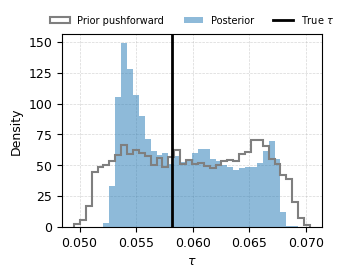

In [58]:
# Push uniform prior draws through the same theta -> tau map used for the posterior.
rng_prior = np.random.default_rng(SEED)
prior_draws = rng_prior.uniform(
    PARAM_BOUNDS[:, 0],
    PARAM_BOUNDS[:, 1],
    size=(len(samples), PARAM_BOUNDS.shape[0]),
)
tau_prior_idw = idw_predict(Xn, tau_sim, normalize_params(prior_draws))

prior_p16, prior_p84 = np.percentile(tau_prior_idw, [16, 84])
post_p16, post_p84 = tau_summary["p16"], tau_summary["p84"]

prior_width = prior_p84 - prior_p16
post_width = post_p84 - post_p16
ratio = post_width / prior_width

print(f"Prior 68% Interval:\t\t[{prior_p16:.4f}, {prior_p84:.4f}]\twidth = {prior_width:.4f}")
print(f"Posterior 68% Interval:\t[{post_p16:.4f}, {post_p84:.4f}]\twidth = {post_width:.4f}")
print(f"Width Ratio (Posterior / Prior):\t{ratio:.2f}")
print()
if ratio < 0.5:
    print("The kSZ data substantially constrains tau beyond the prior.")
elif ratio < 0.8:
    print("The kSZ data modestly constrains tau beyond the prior.")
else:
    print("WARNING: tau is largely prior-dominated; the recovery test is weak evidence "
          "that the data constrains the optical depth.")


fig, ax = plt.subplots()

bin_edges_pp = np.histogram_bin_edges(
    np.concatenate([tau_prior_idw, tau_posterior_idw]), bins=40
)

ax.hist(tau_prior_idw, bins=bin_edges_pp, density=True, histtype="step",
        linewidth=1.5, color="tab:gray", label="Prior pushforward")
ax.hist(tau_posterior_idw, bins=bin_edges_pp, density=True, alpha=0.5,
        color="tab:blue", label="Posterior")
ax.axvline(tau_true_idw, linestyle="-", linewidth=2, color="black", label=r"True $\tau$")

ax.set_xlabel(r"$\tau$")
ax.set_ylabel("Density")

ax.set_axisbelow(True)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
ax.legend(frameon=False, fontsize=7, ncol=3, loc="lower center", bbox_to_anchor=(0.5, 1.0))

fig.savefig(FIG_DIR / f"tau_prior_vs_posterior_{EXPERIMENT_NAME}.pdf",
            format="pdf", bbox_inches="tight")
plt.show()

## Prior vs Posterior Width: All Parameters
Extends the tau-only comparison above to every sampled parameter. This is the
table that decides whether a recovery claim is evidence about the data or an
artefact of the prior.


parameter     prior 68%   post 68%   ratio  improvement           verdict
-------------------------------------------------------------------------
z-bar            1.3600     1.3157    0.97         1.0x   PRIOR-DOMINATED
alpha            0.5440     0.4950    0.91         1.1x   PRIOR-DOMINATED
k_b              1.2920     1.1531    0.89         1.1x   PRIOR-DOMINATED
b_0              0.4760     0.1747    0.37         2.7x       constrained
tau              0.0121     0.0108    0.89         1.1x   PRIOR-DOMINATED

1 of 5 quantities are constrained beyond the prior.
A ratio near 1 means the kSZ bandpowers carry almost no information about
that parameter, so any recovery claim for it rests on the prior.


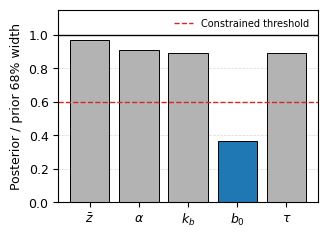

In [59]:
# Prior vs posterior width for EVERY parameter, not just tau.
#
# "The true value lies inside the 68% credible interval" is only evidence that
# the DATA constrained a parameter if the posterior is narrower than the prior.
# When the posterior is essentially the prior, the truth falls inside the 68%
# interval 68% of the time by construction and the recovery test is vacuous.
#
# For a flat prior on [lo, hi] the 16-84 percentile width is exactly
# 0.68 * (hi - lo), so the ratio below is the factor by which the kSZ spectrum
# improved on the prior. tau has no analytic prior width, so its row uses the
# uniform prior draws already pushed through the same IDW map as the posterior.

width_rows = []
for j, name in enumerate(("z-bar", "alpha", "k_b", "b_0")):
    lo, hi = PARAM_BOUNDS[j]
    prior_w = 0.68 * (hi - lo)
    q16, q84 = np.percentile(samples[:, j], [16, 84])
    width_rows.append((name, prior_w, q84 - q16))

tau_prior_w = np.diff(np.percentile(tau_prior_idw, [16, 84]))[0]
tau_post_w = tau_summary["p84"] - tau_summary["p16"]
width_rows.append(("tau", tau_prior_w, tau_post_w))

header = (
    f"{'parameter':<11}{'prior 68%':>12}{'post 68%':>11}"
    f"{'ratio':>8}{'improvement':>13}{'verdict':>18}"
)
print(header)
print("-" * len(header))
for name, pw, ow in width_rows:
    ratio = ow / pw
    verdict = "constrained" if ratio < 0.6 else "PRIOR-DOMINATED"
    print(
        f"{name:<11}{pw:>12.4f}{ow:>11.4f}{ratio:>8.2f}"
        f"{1.0 / ratio:>12.1f}x{verdict:>18}"
    )

n_constrained = sum(1 for _, pw, ow in width_rows if ow / pw < 0.6)
print(
    f"\n{n_constrained} of {len(width_rows)} quantities are constrained beyond the prior."
)
print("A ratio near 1 means the kSZ bandpowers carry almost no information about")
print("that parameter, so any recovery claim for it rests on the prior.")

fig, ax = plt.subplots()

names = [r[0] for r in width_rows]
ratios = [r[2] / r[1] for r in width_rows]
bar_colors = ["tab:blue" if r < 0.6 else "0.7" for r in ratios]

ax.bar(np.arange(len(names)), ratios, color=bar_colors, edgecolor="black", linewidth=0.7)
ax.axhline(1.0, color="black", linestyle="-", linewidth=1.0)
ax.axhline(0.6, color="tab:red", linestyle="--", linewidth=1.0, label="Constrained threshold")

ax.set_xticks(np.arange(len(names)))
ax.set_xticklabels([r"$\bar{z}$", r"$\alpha$", r"$k_b$", r"$b_0$", r"$\tau$"])
ax.set_ylabel("Posterior / prior 68% width")
ax.set_ylim(0.0, 1.15)
ax.legend(frameon=False, fontsize=7)
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

fig.savefig(
    FIG_DIR / f"prior_posterior_width_ratio_{EXPERIMENT_NAME}.pdf",
    format="pdf", bbox_inches="tight",
)
plt.show()


## Method 1: LinearNDInterpolator for Ionization History
- Piecewise-linear interpolation of ionization history over a Delaunay triangulation of the normalized design points; exact at the design points themselves.
- Returns NaN for posterior samples outside the convex hull of the simulations — the printed NaN fraction measures how much of the ionization history posterior relies on unvalidated extrapolation.
- Serves as the cross-check: agreement with IDW shows the ionization history posterior is insensitive to the choice of interpolation method.

In [60]:
ionization_history_linear_interp = LinearNDInterpolator(Xn, xe_sim, fill_value=np.nan)

ionization_history_true_interp = ionization_history_linear_interp(true_n)[0]
ionization_history_mean_interp = ionization_history_linear_interp(posterior_mean_n)[0]
ionization_history_posterior_linear = ionization_history_linear_interp(samples_n)

print("LinearND Ionization History at True Params:", ionization_history_true_interp)
print("LinearND Ionization History at Posterior Mean:", ionization_history_mean_interp)

# Convex-hull coverage: a sample outside the hull is NaN across all z, so we
# flag it per-sample. Reports how much of the ionization-history posterior
# relies on (unvalidated) IDW extrapolation.
outside_hull = np.isnan(ionization_history_posterior_linear).any(axis=1)
nan_frac = outside_hull.mean()
print(f"\nPosterior samples outside convex hull (LinearND NaN): "
      f"{nan_frac * 100:.2f}% ({outside_hull.sum()} / {len(outside_hull)})")
if nan_frac > 0.0:
    print("IDW extrapolates over these samples; treat the IDW ionization history tails with caution.")

LinearND Ionization History at True Params: [5.10770581e-09 3.08650771e-05 2.91330047e-03 3.75562610e-02
 1.56838623e-01 3.48855914e-01 5.48599948e-01 7.10247492e-01
 8.23147821e-01 8.95397939e-01 9.39253408e-01 9.65051485e-01
 9.79964959e-01 9.88510223e-01 9.93384424e-01 9.96176634e-01
 9.97775843e-01 9.98697499e-01 9.99230409e-01 9.99541939e-01
 9.99725785e-01 9.99899642e-01 9.99962005e-01 9.99985433e-01
 9.99993883e-01 9.99997574e-01]
LinearND Ionization History at Posterior Mean: [5.80338990e-06 1.19664205e-04 3.33828876e-03 3.53745697e-02
 1.42994106e-01 3.21210612e-01 5.15027109e-01 6.78995367e-01
 7.98156680e-01 8.77130320e-01 9.26608098e-01 9.56585984e-01
 9.74409782e-01 9.84906164e-01 9.91062569e-01 9.94683361e-01
 9.96815368e-01 9.98077942e-01 9.98830159e-01 9.99282249e-01
 9.99556573e-01 9.99826455e-01 9.99929477e-01 9.99970660e-01
 9.99987165e-01 9.99994390e-01]

Posterior samples outside convex hull (LinearND NaN): 9.72% (1449 / 14912)
IDW extrapolates over these samples; 

## Method 2: IDW for Ionization History
- Inverse-distance-weighted ionization history from the $k = 32$ nearest simulations; defined for every posterior sample, including those outside the convex hull.
- Provides the working ionization history posterior used for the credible intervals, summary statistics, and figures, since it has no missing (NaN) samples.

In [61]:
assert xe_sim.shape[0] == X_sim.shape[0]
assert xe_sim.shape[1] == len(z_grid)

xe_true_idw = idw_predict(Xn, xe_sim, true_n)[0]
xe_mean_idw = idw_predict(Xn, xe_sim, posterior_mean_n)[0]
xe_posterior_idw = idw_predict(Xn, xe_sim, samples_n)

xe_mean = np.mean(xe_posterior_idw, axis=0)
xe_p16 = np.percentile(xe_posterior_idw, 16, axis=0)
xe_p84 = np.percentile(xe_posterior_idw, 84, axis=0)
xe_p025 = np.percentile(xe_posterior_idw, 2.5, axis=0)
xe_p975 = np.percentile(xe_posterior_idw, 97.5, axis=0)

## Plot LinearNDInterpolator Ionization History

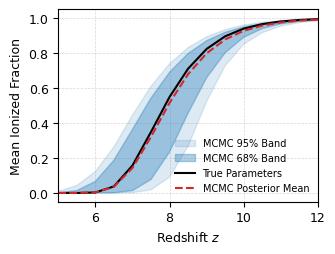

True within 68% band: 100.0% of 26 redshift bins
True within 95% band: 100.0% of 26 redshift bins
The MCMC posterior recovers the full ionization history: the true x_e(z) lies inside the 95% band at every redshift.


In [62]:
# LinearND posterior stats (NaN rows = out-of-hull samples are ignored by nan* funcs)
xe_lin_mean = np.nanmean(ionization_history_posterior_linear, axis=0)
xe_lin_p16  = np.nanpercentile(ionization_history_posterior_linear, 16,   axis=0)
xe_lin_p84  = np.nanpercentile(ionization_history_posterior_linear, 84,   axis=0)
xe_lin_p025 = np.nanpercentile(ionization_history_posterior_linear, 2.5,  axis=0)
xe_lin_p975 = np.nanpercentile(ionization_history_posterior_linear, 97.5, axis=0)

fig, ax = plt.subplots()

ax.fill_between(z_grid, xe_lin_p025, xe_lin_p975, color="tab:blue", alpha=0.15, label="MCMC 95% Band")
ax.fill_between(z_grid, xe_lin_p16, xe_lin_p84, color="tab:blue", alpha=0.35, label="MCMC 68% Band")

ax.plot(z_grid, ionization_history_true_interp, color="black", linewidth=1.5, label="True Parameters")
ax.plot(z_grid, ionization_history_mean_interp, "--", color="tab:red", linewidth=1.5, label="MCMC Posterior Mean")

# ax.set_xlim(z_grid.min(), 14)
ax.set_xlim(5, 12)
ax.set_xlabel("Redshift $z$")
ax.set_ylabel(r"Mean Ionized Fraction")

ax.set_axisbelow(True)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax.legend(frameon=False, fontsize=7, loc="lower right")

fig.savefig(FIG_DIR / f"ionization_history_posterior_linear_{EXPERIMENT_NAME}.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Quantitative validation: does the true x_e lie within the LinearND credible bands?
inside_68 = (ionization_history_true_interp >= xe_lin_p16) & (ionization_history_true_interp <= xe_lin_p84)
inside_95 = (ionization_history_true_interp >= xe_lin_p025) & (ionization_history_true_interp <= xe_lin_p975)

frac_68 = inside_68.mean()
frac_95 = inside_95.mean()

print(f"True within 68% band: {frac_68 * 100:.1f}% of {len(z_grid)} redshift bins")
print(f"True within 95% band: {frac_95 * 100:.1f}% of {len(z_grid)} redshift bins")

if frac_95 == 1.0:
    print("The MCMC posterior recovers the full ionization history: the true x_e(z) lies inside the 95% band at every redshift.")
else:
    bad = z_grid[~inside_95]
    print(f"True x_e(z) falls outside the 95% band at z = {np.array2string(bad, precision=2)}")

## Plot IDW Ionization History

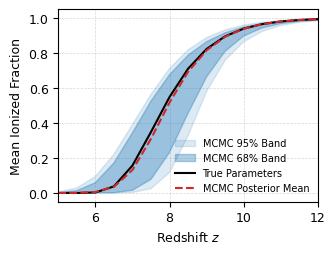

True within 68% band: 100.0% of 26 redshift bins
True within 95% band: 100.0% of 26 redshift bins
The MCMC posterior recovers the full ionization history: the true x_e(z) lies inside the 95% band at every redshift.


In [63]:
fig, ax = plt.subplots()

ax.fill_between(z_grid, xe_p025, xe_p975, color="tab:blue", alpha=0.15, label="MCMC 95% Band")
ax.fill_between(z_grid, xe_p16, xe_p84, color="tab:blue", alpha=0.35, label="MCMC 68% Band")

ax.plot(z_grid, xe_true_idw, color="black", linewidth=1.5, label="True Parameters")
ax.plot(z_grid, xe_mean_idw, "--", color="tab:red", linewidth=1.5, label="MCMC Posterior Mean")

# ax.set_xlim(z_grid.min(), 14)
ax.set_xlim(5, 12)
ax.set_xlabel("Redshift $z$")
ax.set_ylabel(r"Mean Ionized Fraction")

ax.set_axisbelow(True)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax.legend(frameon=False, fontsize=7, loc="lower right")

fig.savefig(FIG_DIR / f"ionization_history_posterior_{EXPERIMENT_NAME}.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Quantitative validation: does the true xm lie within the credible bands?
inside_68 = (xe_true_idw >= xe_p16) & (xe_true_idw <= xe_p84)
inside_95 = (xe_true_idw >= xe_p025) & (xe_true_idw <= xe_p975)

frac_68 = inside_68.mean()
frac_95 = inside_95.mean()

print(f"True within 68% band: {frac_68 * 100:.1f}% of {len(z_grid)} redshift bins")
print(f"True within 95% band: {frac_95 * 100:.1f}% of {len(z_grid)} redshift bins")

if frac_95 == 1.0:
    print("The MCMC posterior recovers the full ionization history: the true x_e(z) lies inside the 95% band at every redshift.")
else:
    bad = z_grid[~inside_95]
    print(f"True x_e(z) falls outside the 95% band at z = {np.array2string(bad, precision=2)}")

## Percent Error for Tau and Ionization History (Most Central Case)

In [97]:
# Tau: posterior mean against the true value.
tau_percent_error = 100.0 * abs(tau_summary["mean"] - tau_true_idw) / tau_true_idw

print(f"Tau True:\t\t\t{tau_true_idw:.4f}")
print(f"Tau Posterior Mean:\t{tau_summary['mean']:.4f}")
print(f"Tau Percent Error:\t{tau_percent_error:.2f}%")

# Ionization history: mean fractional error where reionization is in progress.
# Restricted to 0.05 < x < 0.95 because the fractional error is undefined as
# x -> 0 and saturates as x -> 1.
xe_true = ionization_history_true_interp
xe_post = ionization_history_mean_interp
mask = (xe_true > 0.05) & (xe_true < 0.95)

xe_abs_error = np.mean(np.abs(xe_post[mask] - xe_true[mask]))
xe_percent_error = 100.0 * np.mean(np.abs(xe_post[mask] - xe_true[mask]) / xe_true[mask])

print(f"\nBins Used:\t\t\t{mask.sum()} of {len(z_grid)}")
print(f"Redshift Range:\t\tz = {z_grid[mask].min():.1f} to {z_grid[mask].max():.1f}")
print(f"Mean Absolute Error:\t{xe_abs_error:.4f}")
print(f"Mean Percent Error:\t{xe_percent_error:.2f}%")

Tau True:			0.0582
Tau Posterior Mean:	0.0593
Tau Percent Error:	1.94%

Bins Used:			7 of 26
Redshift Range:		z = 7.0 to 10.0
Mean Absolute Error:	0.0232
Mean Percent Error:	4.81%


## Full Pipeline Over N Random Held-Out Simulations
- For each case:  mock obs -> MCMC -> posterior -> LinearND

In [64]:
# Config
NSTEPS   = 30_000
NWALKERS = 32
NDIM     = 4
DISCARD, THIN = 1000, 100
N_CASES  = 5

# Build the LinearND interpolator
Xn = normalize_params(X_sim)
ih_interp = LinearNDInterpolator(Xn, xe_sim, fill_value=np.nan)

if RUN_RANDOM_CASES:
    rng = np.random.default_rng(SEED)

    # Pick N_CASES random held-out points (all of them, shuffled, if <= N_CASES exist)
    n_heldout   = len(X_heldout)
    n_cases     = min(N_CASES, n_heldout)
    case_idx    = rng.choice(n_heldout, size=n_cases, replace=False)
    print(f"Running the pipeline on {n_cases} held-out cases: "
          f"test-set idx {case_idx.tolist()} "
          f"(global idx {heldout_indices[case_idx].tolist()})")

    # Loop: full pipeline per case
    results = []
    # Loop variables are prefixed `case_` so this batch run does not overwrite the
    # single-mock analysis above (true_params, observed_dl, samples, sampler, ...).
    for n, idx in enumerate(case_idx):
        case_true_params = X_heldout[idx]
        case_observed_dl = np.exp(Y_heldout[idx])
        case_sigma_obs   = 0.10 * case_observed_dl

        # MCMC (independent, reproducible init per case)
        case_initial_pos = case_true_params + 1e-2 * rng.standard_normal((NWALKERS, NDIM))
        for j, (low, high) in enumerate(PARAM_BOUNDS):
            case_initial_pos[:, j] = np.clip(case_initial_pos[:, j], low, high)

        case_sampler = emcee.EnsembleSampler(
            NWALKERS, NDIM, log_probability, args=(case_observed_dl, case_sigma_obs)
        )
        print(f"\n[{n + 1}/{n_cases}] test-set idx {idx} — running {NSTEPS:,} steps...")
        case_sampler.run_mcmc(case_initial_pos, NSTEPS, progress=True)

        # Posterior
        case_samples        = case_sampler.get_chain(discard=DISCARD, thin=THIN, flat=True)
        case_posterior_mean = case_samples.mean(axis=0)

        # Normalize + LinearND ionization history
        case_samples_n        = normalize_params(case_samples)
        case_true_n           = normalize_params(case_true_params[None, :])
        case_posterior_mean_n = normalize_params(case_posterior_mean[None, :])

        ih_true = ih_interp(case_true_n)[0]
        ih_mean = ih_interp(case_posterior_mean_n)[0]
        ih_post = ih_interp(case_samples_n)                # (n_samples, n_z)

        outside_hull = np.isnan(ih_post).any(axis=1)
        ih_p16 = np.nanpercentile(ih_post, 16, axis=0)
        ih_p84 = np.nanpercentile(ih_post, 84, axis=0)
        print(f"    acceptance={np.mean(case_sampler.acceptance_fraction):.3f}  "
              f"out-of-hull={outside_hull.mean() * 100:.1f}%")

        results.append(dict(
            idx=int(idx), global_idx=int(heldout_indices[idx]),
            true_params=case_true_params, ih_true=ih_true, ih_mean=ih_mean,
            ih_p16=ih_p16, ih_p84=ih_p84, nan_frac=float(outside_hull.mean()),
        ))
else:
    print("RUN_RANDOM_CASES = False: skipped.")


Running the pipeline on 5 held-out cases: test-set idx [152, 87, 129, 17, 86] (global idx [15, 599, 313, 640, 718])

[1/5] test-set idx 152 — running 30,000 steps...


100%|██████████| 30000/30000 [19:30<00:00, 25.63it/s]


    acceptance=0.407  out-of-hull=12.3%

[2/5] test-set idx 87 — running 30,000 steps...


100%|██████████| 30000/30000 [20:08<00:00, 24.82it/s]


    acceptance=0.452  out-of-hull=13.6%

[3/5] test-set idx 129 — running 30,000 steps...


...

    acceptance=0.427  out-of-hull=8.4%

[4/5] test-set idx 17 — running 30,000 steps...


100%|██████████| 30000/30000 [19:38<00:00, 25.45it/s]


    acceptance=0.446  out-of-hull=23.6%

[5/5] test-set idx 86 — running 30,000 steps...


100%|██████████| 30000/30000 [18:52<00:00, 26.49it/s]

    acceptance=0.401  out-of-hull=9.1%


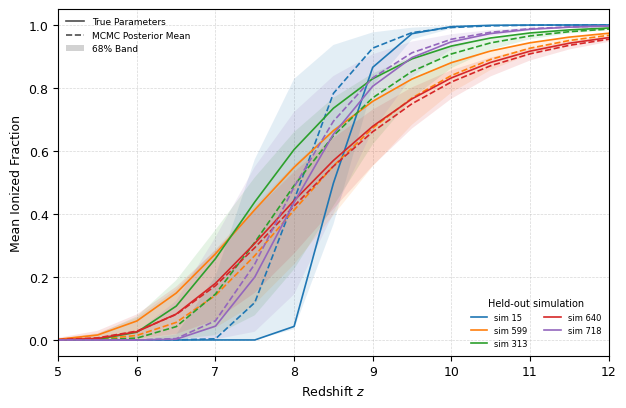

In [65]:
if RUN_RANDOM_CASES:
    # Combined plot: all 10 ionization histories
    colors = plt.cm.tab10(np.linspace(0, 1, 10))

    fig, ax = plt.subplots(figsize=(7.1, 4.5))

    for r, c in zip(results, colors):
        ax.fill_between(z_grid, r["ih_p16"], r["ih_p84"], color=c, alpha=0.12, linewidth=0)
        ax.plot(z_grid, r["ih_mean"], "--", color=c, linewidth=1.2)
        ax.plot(z_grid, r["ih_true"], "-",  color=c, linewidth=1.2,
                label=f"sim {r['global_idx']}")

    ax.set_xlim(5, 12)
    ax.set_xlabel("Redshift $z$")
    ax.set_ylabel(r"Mean Ionized Fraction")
    ax.set_axisbelow(True)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

    # Legend 1: one colored entry per simulation
    leg1 = ax.legend(frameon=False, fontsize=6, ncol=2, loc="lower right",
                     title="Held-out simulation")
    plt.setp(leg1.get_title(), fontsize=7)
    ax.add_artist(leg1)

    # Legend 2: line-style convention (solid=true, dashed=posterior mean, band=68%)
    style_handles = [
        Line2D([0], [0], color="0.3", linestyle="-",  linewidth=1.2, label="True Parameters"),
        Line2D([0], [0], color="0.3", linestyle="--", linewidth=1.2, label="MCMC Posterior Mean"),
        Patch(facecolor="0.3", alpha=0.25, label="68% Band"),
    ]
    ax.legend(handles=style_handles, frameon=False, fontsize=6.5, loc="upper left")

    fig.savefig(FIG_DIR / f"ionization_history_posterior_linearnd_random_{N_CASES}_{EXPERIMENT_NAME}.pdf",
                format="pdf", bbox_inches="tight")
    plt.show()
else:
    print('RUN_RANDOM_CASES = False: no random-case results to plot.')


## Percent Error for Tau and Ionization History (Random Set)

In [101]:
if RUN_RANDOM_CASES:
    case_errors = []
    for r in results:
        xe_t, xe_p = r["ih_true"], r["ih_mean"]
        m = (xe_t > 0.05) & (xe_t < 0.95)
        case_errors.append(100.0 * np.mean(np.abs(xe_p[m] - xe_t[m]) / xe_t[m]))
    case_errors = np.asarray(case_errors)
    for r, e in zip(results, case_errors):
        print(f"Test-Set Index {r['idx']:>4}:\t{e:.2f}%")
    print(f"\nMean:\t{case_errors.mean():.2f}%")
    print(f"STD:\t{case_errors.std(ddof=1):.2f}%")
    print(f"Range:\t{case_errors.min():.2f}% to {case_errors.max():.2f}%")

Test-Set Index  152:	32.15%
Test-Set Index   87:	26.49%
Test-Set Index  129:	22.33%
Test-Set Index   17:	2.40%
Test-Set Index   86:	7.34%

Mean:	18.14%
STD:	12.73%
Range:	2.40% to 32.15%


## Full Pipeline Over N Best-Case Simulations (Closest to the Center of Param Space)
- For each case:  mock obs -> MCMC -> posterior -> LinearND

In [66]:
# Config
NSTEPS   = 30_000
NWALKERS = 32
NDIM     = 4
DISCARD, THIN = 1000, 100
N_CASES  = 5

# Build the LinearND interpolator ONCE (Xn / xe_sim are fixed across cases)
Xn = normalize_params(X_sim)
ih_interp = LinearNDInterpolator(Xn, xe_sim, fill_value=np.nan)

if RUN_CENTRAL_CASES:
    rng = np.random.default_rng(SEED)

    case_idx = np.asarray(central_order[:N_CASES])
    n_cases  = len(case_idx)

    # Guard against `central_order` being rebound by an intervening cell: these must
    # be the held-out sims closest to the centre of the prior volume.
    _dist_check = np.linalg.norm(
        (X_heldout[case_idx] - PARAM_BOUNDS[:, 0])
        / (PARAM_BOUNDS[:, 1] - PARAM_BOUNDS[:, 0]) - 0.5,
        axis=1,
    )
    assert np.all(np.diff(_dist_check) >= 0), (
        "case_idx is not ordered by distance to the centre of parameter space"
    )
    print(f"Distances to centre: {np.round(_dist_check, 3).tolist()}")
    print(f"Running the pipeline on {n_cases} central held-out cases: "
          f"test-set idx {case_idx.tolist()} "
          f"(global idx {heldout_indices[case_idx].tolist()})")

    # Loop: full pipeline per case
    results = []
    # Loop variables are prefixed `case_` so this batch run does not overwrite the
    # single-mock analysis above (true_params, observed_dl, samples, sampler, ...).
    for n, idx in enumerate(case_idx):
        case_true_params = X_heldout[idx]
        case_observed_dl = np.exp(Y_heldout[idx])
        case_sigma_obs   = 0.10 * case_observed_dl

        # MCMC (independent, reproducible init per case)
        case_initial_pos = case_true_params + 1e-2 * rng.standard_normal((NWALKERS, NDIM))
        for j, (low, high) in enumerate(PARAM_BOUNDS):
            case_initial_pos[:, j] = np.clip(case_initial_pos[:, j], low, high)

        case_sampler = emcee.EnsembleSampler(
            NWALKERS, NDIM, log_probability, args=(case_observed_dl, case_sigma_obs)
        )
        print(f"\n[{n + 1}/{n_cases}] test-set idx {idx} — running {NSTEPS:,} steps...")
        case_sampler.run_mcmc(case_initial_pos, NSTEPS, progress=True)

        # Posterior
        case_samples        = case_sampler.get_chain(discard=DISCARD, thin=THIN, flat=True)
        case_posterior_mean = case_samples.mean(axis=0)

        # Normalize + LinearND ionization history
        case_samples_n        = normalize_params(case_samples)
        case_true_n           = normalize_params(case_true_params[None, :])
        case_posterior_mean_n = normalize_params(case_posterior_mean[None, :])

        ih_true = ih_interp(case_true_n)[0]
        ih_mean = ih_interp(case_posterior_mean_n)[0]
        ih_post = ih_interp(case_samples_n)                # (n_samples, n_z)

        outside_hull = np.isnan(ih_post).any(axis=1)
        ih_p16 = np.nanpercentile(ih_post, 16, axis=0)
        ih_p84 = np.nanpercentile(ih_post, 84, axis=0)
        print(f"    acceptance={np.mean(case_sampler.acceptance_fraction):.3f}  "
              f"out-of-hull={outside_hull.mean() * 100:.1f}%")

        results.append(dict(
            idx=int(idx), global_idx=int(heldout_indices[idx]),
            true_params=case_true_params, ih_true=ih_true, ih_mean=ih_mean,
            ih_p16=ih_p16, ih_p84=ih_p84, nan_frac=float(outside_hull.mean()),
        ))
else:
    print("RUN_CENTRAL_CASES = False: skipped.")


RUN_CENTRAL_CASES = False: skipped.


In [67]:
if RUN_CENTRAL_CASES:
    colors = plt.cm.tab10(np.arange(n_cases))

    fig, ax = plt.subplots(figsize=(7.1, 4.5))

    for r, c in zip(results, colors):
        ax.fill_between(z_grid, r["ih_p16"], r["ih_p84"], color=c, alpha=0.12, linewidth=0)
        ax.plot(z_grid, r["ih_mean"], "--", color=c, linewidth=1.2)
        ax.plot(z_grid, r["ih_true"], "-",  color=c, linewidth=1.2,
                label=f"sim {r['global_idx']}")

    ax.set_xlim(5, 12)
    ax.set_xlabel("Redshift $z$")
    ax.set_ylabel(r"Mean Ionized Fraction")
    ax.set_axisbelow(True)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

    # Legend 1: one colored entry per simulation
    leg1 = ax.legend(frameon=False, fontsize=6, ncol=2, loc="lower right",
                     title="Held-out simulation")
    plt.setp(leg1.get_title(), fontsize=7)
    ax.add_artist(leg1)

    # Legend 2: line-style convention (solid=true, dashed=posterior mean, band=68%)
    style_handles = [
        Line2D([0], [0], color="0.3", linestyle="-",  linewidth=1.2, label="True Parameters"),
        Line2D([0], [0], color="0.3", linestyle="--", linewidth=1.2, label="MCMC Posterior Mean"),
        Patch(facecolor="0.3", alpha=0.25, label="68% Band"),
    ]
    ax.legend(handles=style_handles, frameon=False, fontsize=6.5, loc="upper left")

    fig.savefig(FIG_DIR / f"ionization_history_posterior_linearnd_best_{n_cases}_{EXPERIMENT_NAME}.pdf",
                format="pdf", bbox_inches="tight")
    plt.show()
else:
    print('RUN_CENTRAL_CASES = False: no central-case results to plot.')


RUN_CENTRAL_CASES = False: no central-case results to plot.


# Simulation-Based Calibration
---
Replaces the single-mock recovery test with a frequency statement over many
mocks: noise realizations are drawn, walkers are dispersed over the prior, and
the statistic is the rank of the true value inside the posterior.


In [68]:
%%time
# Simulation-based calibration.
#
# Every recovery test above uses ONE mock, with no noise realization drawn and
# walkers started at the truth. That design cannot fail. SBC replaces it with a
# frequency statement: over many mocks, does the posterior contain the truth as
# often as it claims?
#
# Three deliberate departures from the single-mock analysis:
#   1. A noise realization IS drawn:  observed = truth + sigma_obs * N(0, 1).
#   2. Walkers are dispersed UNIFORMLY OVER THE PRIOR, not seeded at the truth.
#   3. The statistic is the rank of the true value within the posterior samples.
#      Under correct calibration those ranks are Uniform(0, n_samples), tested
#      here with a KS test against the uniform.
#
# Cost control (this is what makes 100 mocks affordable):
#   - tau ~ 127 from the diagnostics above, so 5,000 steps already gives
#     N/tau ~ 39 per walker; 30,000 was far more than needed.
#   - vectorize=True hands emcee all 32 walkers at once, so each step becomes a
#     single batched predict_mc call instead of 32 separate ones. Measured
#     speedup 11x (12.7 -> 143 steps/s), verified to be distributionally
#     identical to the scalar likelihood.
#   - n_mc_samples is raised to N_MC_LIKELIHOOD (201) rather than the 100 used
#     by the single-chain likelihood, which the stability analysis called for.
#
# torch RNG state is saved and restored so this block cannot perturb any earlier
# reported number if it is inserted into an otherwise-complete run.

SBC_N_MOCKS = 100
SBC_NSTEPS = 5_000
SBC_NWALKERS = 32
SBC_DISCARD, SBC_THIN = 2_000, 50
N_MC_LIKELIHOOD = 201

_LO, _HI = PARAM_BOUNDS[:, 0], PARAM_BOUNDS[:, 1]


def log_probability_vectorized(thetas, observed, sigma):
    """
    Vectorised log-posterior for emcee(vectorize=True).

    thetas: (nwalkers, ndim). Returns (nwalkers,). Walkers outside the flat prior
    get -inf and are excluded from the batched forward pass entirely.
    """
    thetas = np.atleast_2d(np.asarray(thetas, dtype=np.float64))
    out = np.full(len(thetas), -np.inf)

    inside = np.all((thetas >= _LO) & (thetas <= _HI), axis=1)
    if not inside.any():
        return out

    model_dl, emulator_std, _, _ = predict_mc(
        thetas[inside], model, norms["X"].mean, norms["X"].std,
        normalize_X=True, n_mc_samples=N_MC_LIKELIHOOD,
    )
    sigma_total = np.sqrt(sigma**2 + emulator_std**2)
    chi2 = np.sum(((observed - model_dl) / sigma_total) ** 2, axis=1)
    log_det = np.sum(np.log(2.0 * np.pi * sigma_total**2), axis=1)
    out[inside] = -0.5 * (chi2 + log_det)
    return out


if RUN_SBC:
    _torch_state = torch.get_rng_state()
    try:
            sbc_rng = np.random.default_rng(SEED)
            sbc_case_idx = sbc_rng.choice(
                len(X_heldout), size=min(SBC_N_MOCKS, len(X_heldout)), replace=False
            )

            sbc_ranks, sbc_acceptance = [], []
            sbc_n_samples = None
            _t0 = time.time()

            for n, ci in enumerate(sbc_case_idx):
                theta_true = X_heldout[ci].astype(np.float64)
                true_dl = np.exp(Y_heldout[ci])
                sigma_obs_n = 0.10 * true_dl

                # the noise realization that the single-mock test omits
                observed_n = true_dl + sigma_obs_n * sbc_rng.standard_normal(len(true_dl))

                # dispersed init: uniform over the prior, NOT a ball around the truth
                p0 = sbc_rng.uniform(_LO, _HI, size=(SBC_NWALKERS, len(_LO)))

                sbc_sampler = emcee.EnsembleSampler(
                    SBC_NWALKERS, len(_LO), log_probability_vectorized,
                    args=(observed_n, sigma_obs_n), vectorize=True,
                )
                sbc_sampler.run_mcmc(p0, SBC_NSTEPS, progress=False)

                post = sbc_sampler.get_chain(
                    discard=SBC_DISCARD, thin=SBC_THIN, flat=True
                )
                sbc_acceptance.append(float(np.mean(sbc_sampler.acceptance_fraction)))
                sbc_n_samples = len(post)

                # tau is a derived quantity, so rank it through the same IDW map
                tau_true_n = idw_predict(Xn, tau_sim, normalize_params(theta_true[None, :]))[0]
                tau_post_n = idw_predict(Xn, tau_sim, normalize_params(post))

                row = [int(np.sum(post[:, j] < theta_true[j])) for j in range(len(_LO))]
                row.append(int(np.sum(tau_post_n < tau_true_n)))
                sbc_ranks.append(row)

                if (n + 1) % 10 == 0 or n == 0:
                    print(f"  [{n + 1}/{len(sbc_case_idx)}] "
                          f"{time.time() - _t0:6.1f}s  acc={sbc_acceptance[-1]:.3f}")

            sbc_ranks = np.asarray(sbc_ranks)
            sbc_acceptance = np.asarray(sbc_acceptance)
            print(f"\n{len(sbc_ranks)} mocks in {time.time() - _t0:.1f}s; "
                  f"{sbc_n_samples} posterior samples each; "
                  f"mean acceptance {sbc_acceptance.mean():.3f}")
    finally:
        torch.set_rng_state(_torch_state)
else:
    print("RUN_SBC = False: skipped.")


RUN_SBC = False: skipped.
CPU times: user 83 μs, sys: 26 μs, total: 109 μs
Wall time: 105 μs


## SBC Results: Rank Uniformity and Coverage


In [69]:
if RUN_SBC:
    # SBC results: rank uniformity and empirical credible-interval coverage.
    #
    # Reading the table:
    #   KS p          - probability the ranks are uniform. p < 0.05 means detectable
    #                   miscalibration. p > 0.05 is NOT proof of calibration, only
    #                   absence of evidence against it at this sample size.
    #   mean rank     - 0.5 if unbiased; < 0.5 means the posterior sits high relative
    #                   to the truth, > 0.5 means it sits low.
    #   68% / 95% cov - fraction of mocks whose true value fell inside the central
    #                   credible interval. These are the numbers a referee wants.
    #
    # The binomial standard error on a coverage estimate from N mocks is
    # sqrt(p(1-p)/N); it is printed so the table is not over-read.

    from scipy.stats import kstest

    sbc_labels = ["z-bar", "alpha", "k_b", "b_0", "tau"]
    sbc_u = sbc_ranks / sbc_n_samples
    n_mocks = len(sbc_u)

    se68 = np.sqrt(0.683 * 0.317 / n_mocks) * 100
    se95 = np.sqrt(0.954 * 0.046 / n_mocks) * 100

    header = f"{'quantity':<10}{'KS p':>8}{'mean rank':>11}{'68% cov':>10}{'95% cov':>10}"
    print(f"SBC over {n_mocks} mocks, {sbc_n_samples} posterior samples each")
    print(f"binomial SE: +-{se68:.1f}% on the 68% column, +-{se95:.1f}% on the 95% column\n")
    print(header)
    print("-" * len(header))
    print(f"{'ideal':<10}{'>0.05':>8}{0.500:>11.3f}{68.3:>10.1f}{95.4:>10.1f}")

    sbc_table = []
    for j, lab in enumerate(sbc_labels):
        p = kstest(sbc_u[:, j], "uniform").pvalue
        c68 = np.mean((sbc_u[:, j] > 0.16) & (sbc_u[:, j] < 0.84)) * 100
        c95 = np.mean((sbc_u[:, j] > 0.025) & (sbc_u[:, j] < 0.975)) * 100
        sbc_table.append((lab, p, sbc_u[:, j].mean(), c68, c95))
        print(f"{lab:<10}{p:>8.3f}{sbc_u[:, j].mean():>11.3f}{c68:>10.1f}{c95:>10.1f}")

    flagged = [t[0] for t in sbc_table if t[1] < 0.05]
    if flagged:
        print(f"\nDetectable miscalibration (KS p < 0.05): {', '.join(flagged)}")
    else:
        print(f"\nNo detectable miscalibration at n = {n_mocks}.")
    print("Note: with a prior-dominated posterior, near-nominal coverage is expected")
    print("almost by construction and is weak evidence that the likelihood is right.")

    fig, ax = plt.subplots(1, 5, figsize=(7.1, 1.9), sharey=True)
    nbins = 10
    band_lo, band_hi = None, None
    for j, lab in enumerate(sbc_labels):
        counts, _ = np.histogram(sbc_u[:, j], bins=nbins, range=(0.0, 1.0))
        expected = n_mocks / nbins
        band = np.sqrt(expected * (1.0 - 1.0 / nbins))
        band_lo, band_hi = expected - band, expected + band

        ax[j].axhspan(band_lo, band_hi, color="0.85", zorder=0)
        ax[j].axhline(expected, color="black", linestyle="--", linewidth=0.8, zorder=1)
        ax[j].bar(
            np.arange(nbins) + 0.5, counts, width=0.9, color="tab:blue",
            edgecolor="black", linewidth=0.5, zorder=2,
        )
        ax[j].set_xlim(0, nbins)
        ax[j].set_xticks([0, nbins])
        ax[j].set_xticklabels(["0", "1"], fontsize=7)
        ax[j].set_title(lab, fontsize=8)
        ax[j].tick_params(labelsize=7)

    ax[0].set_ylabel("Count", fontsize=8)
    fig.supxlabel("Normalised rank of true value", fontsize=8, y=-0.06)

    plt.tight_layout()
    fig.savefig(
        FIG_DIR / f"sbc_rank_histograms_{EXPERIMENT_NAME}.pdf",
        format="pdf", bbox_inches="tight",
    )
    plt.show()
else:
    print('RUN_SBC = False: no SBC ranks to summarise.')


RUN_SBC = False: no SBC ranks to summarise.


# Save Checkpoint / Artifact / Requirements
---

In [70]:
CKPT_DIR.mkdir(parents=True, exist_ok=True)
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "model_config": modelcfg,
        "normalize_X": dlcfg.normalize_X,
        "normalize_Y": dlcfg.normalize_Y,
    },
    MODEL_PATH,
)
print(f"Model saved to {MODEL_PATH}")

NORM_PATH.mkdir(parents=True, exist_ok=True)
if norms["X"] is not None:
    np.save(NORM_PATH / "X_mean.npy", norms["X"].mean)
    np.save(NORM_PATH / "X_std.npy", norms["X"].std)
if norms["Y"] is not None:
    np.save(NORM_PATH / "Y_mean.npy", norms["Y"].mean)
    np.save(NORM_PATH / "Y_std.npy", norms["Y"].std)
np.save(NORM_PATH / "ell.npy", np.asarray(ell))
print(f"Normalizers saved to {NORM_PATH}")

# Only written when the chain was actually re-run, so a cached run cannot degrade
# the stored chain.
if RUN_SINGLE_MCMC:
    np.save(CKPT_DIR / "mcmc_chain.npy", sampler.get_chain())
    np.save(CKPT_DIR / "mcmc_log_prob.npy", sampler.get_log_prob())
    np.save(CKPT_DIR / "mcmc_acceptance.npy", sampler.acceptance_fraction)
    np.save(CKPT_DIR / "mcmc_true_params.npy", true_params)
    print(f"MCMC chain saved to {CKPT_DIR / 'mcmc_chain.npy'}")
else:
    print("RUN_SINGLE_MCMC=False: kept the existing cached chain, nothing overwritten.")

Model saved to /Users/robertxpearce/Desktop/Research/LEADS Lab/Reionization Emulator/Code/reionization-emulator/checkpoints/pearce_2026_reionemu_mc_dropout/mc_dropout_n_mc_201_epochs_1000_early_stop_150/model.pt
Normalizers saved to /Users/robertxpearce/Desktop/Research/LEADS Lab/Reionization Emulator/Code/reionization-emulator/checkpoints/pearce_2026_reionemu_mc_dropout/mc_dropout_n_mc_201_epochs_1000_early_stop_150/norm
MCMC chain saved to /Users/robertxpearce/Desktop/Research/LEADS Lab/Reionization Emulator/Code/reionization-emulator/checkpoints/pearce_2026_reionemu_mc_dropout/mc_dropout_n_mc_201_epochs_1000_early_stop_150/mcmc_chain.npy


In [71]:
artifact = save_artifact(
    f"mc_dropout_experiment_{EXPERIMENT_NAME}",
    ARTIFACT_DIR,
    dataset_path=H5_PATH,
    condense_config=cdcfg,
    cl_config=clcfg,
    build_config=xycfg,
    dataloader_config=dlcfg,
    fit_config=fitcfg,
    kfold_config=kfcfg,
    model_config=modelcfg,
    optimizer_config = {"lr":1e-3, "weight_decay": 1e-5},
    metrics = {
        "heldout_mse": test_mse,
        "heldout_mae": test_mae,
        "heldout_rmse": test_rmse,
        
        "heldout_mean_percent_error": percent_err,
        "heldout_mean_predictive_std": heldout_pred_std.mean(axis=0),
        "heldout_mean_predictive_std_overall": float(heldout_pred_std.mean()),
        
        "heldout_coverage_1sigma": phy_coverage_1sigma,
        "heldout_coverage_2sigma": phy_coverage_2sigma,
        "heldout_coverage_3sigma": phy_coverage_3sigma,
        "heldout_z_percentiles": {
            "p50": float(np.percentile(z_score, 50)),
            "p68": float(np.percentile(z_score, 68)),
            "p90": float(np.percentile(z_score, 90)),
            "p95": float(np.percentile(z_score, 95)),
            "p99": float(np.percentile(z_score, 99)),
            "max": float(np.max(z_score)),
        },
    },
    history = {
        "train": train_results,
        "kfold_mean_val": kfold_results["mean_best_val"],
        # Protocol tags: the k-fold and training losses are scored differently
        # and must not be compared to one another.
        "kfold_evaluation": "evaluate_metrics",
        "train_evaluation": "evaluate_mc_metrics",
        "final_val_deterministic": final_val_deterministic,
    },
    dataset_prep_stats = {
        "condense": condense_stats,
        "cl": cl_stats,
        "build_xy": xy_stats,
        
        "split_info": {
            "heldout_indices": heldout_indices.tolist(),
            "random_seed": SEED,
        },
    },
    normalizers = {"X_norm": norms["X"]},
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "model_config": modelcfg,
        "normalize_X": dlcfg.normalize_X,
        "normalize_Y": dlcfg.normalize_Y,
    },
    description = (
        f"Experiment using MC dropout model referenced in publication ({EXPERIMENT_NAME})."
        f"Figures are located in: {FIG_DIR.resolve()}"
    )
)

In [72]:
!pip list --format=freeze > requirements.txt

# Background Figures
- Data pulled from `sims` is not sorted the same as `training`
---

## Simulation Output

In [73]:
with h5py.File(H5_PATH, "r") as h5f:
    print("Simulation 1")
    print("Parameters:\n", list(h5f["sims"]["sim1"]["params"]))
    print(f"\t zmean_zre: {h5f["sims"]["sim1"]["params"]["zmean_zre"][()]}")
    print(f"\t alpha_zre: {h5f["sims"]["sim1"]["params"]["alpha_zre"][()]}")
    print(f"\t kb_zre: {h5f["sims"]["sim1"]["params"]["kb_zre"][()]}")
    print(f"\t b0_zre: {h5f["sims"]["sim1"]["params"]["b0_zre"][()]}")
    
    print("Output:\n", list(h5f["sims"]["sim1"]["output"]))
    print(f"\t ksz_map Shape: {h5f['sims']['sim1']['output']['ksz_map'].shape}")
    print(f"\t theta_max_ksz: {h5f['sims']['sim1']['output']['theta_max_ksz'][()]} \t Degrees: {np.degrees(h5f['sims']['sim1']['output']['theta_max_ksz'][()])}")
    print(f"\t Tcmb0: {h5f['sims']['sim1']['output']['Tcmb0'][()]}")
    print(f"\t Tau: {h5f['sims']['sim1']['output']['tau'][()]}")
    print(f"\t zval_list Shape: {h5f['sims']['sim1']['output']['zval_list'].shape}")
    print(f"\t xmval_list Shape: {h5f['sims']['sim1']['output']['xmval_list'].shape}")
    print(f"\t pk_tt Shape: {h5f['sims']['sim1']['output']['pk_tt'].shape}")
    
    print("Cl:\n", list(h5f["sims"]["sim1"]["cl"]))
    print(f"\t cl_ksz: {h5f['sims']['sim1']['cl']['cl_ksz'][()]} \t Shape: {h5f['sims']['sim1']['cl']['cl_ksz'].shape}")
    print(f"\t dl_ksz: {h5f['sims']['sim1']['cl']['dl_ksz'][()]} \t Shape: {h5f['sims']['sim1']['cl']['dl_ksz'].shape}")
    print(f"\t ell: {h5f['sims']['sim1']['cl']['ell'][()]} \t Shape: {h5f['sims']['sim1']['cl']['ell'].shape}")
    
    print(f"{h5f['sims']['sim1']['output']['theta_max_ksz'][()]}")

Simulation 1
Parameters:
 ['alpha_zre', 'b0_zre', 'kb_zre', 'zmean_zre']
	 zmean_zre: 8.88764818819783
	 alpha_zre: 0.4329503243946754
	 kb_zre: 0.1020456445037486
	 b0_zre: 0.24680639792154205
Output:
 ['Tcmb0', 'ksz_map', 'pk_tt', 'tau', 'theta_max_ksz', 'xmval_list', 'zval_list']
	 ksz_map Shape: (1024, 1024)
	 theta_max_ksz: 0.2843331859916941 	 Degrees: 16.291091532832333
	 Tcmb0: 2.7255
	 Tau: 0.0670870825453519
	 zval_list Shape: (26,)
	 xmval_list Shape: (26,)
	 pk_tt Shape: (26, 1024, 3)
Cl:
 ['cl_ksz', 'dcl', 'dl_ksz', 'ell']
	 cl_ksz: [1.33404460e-06 2.37077920e-07 7.04054364e-08 2.90737632e-08
 1.69774180e-08] 	 Shape: (5,)
	 dl_ksz: [0.87839689 0.63239574 0.42434385 0.31217971 0.28519583] 	 Shape: (5,)
	 ell: [ 2033.49633959  4093.41528716  6153.33423472  8213.25318229
 10273.17212985] 	 Shape: (5,)
0.2843331859916941


## Parameter-Space Sampling

In [74]:
rows = []

with h5py.File(H5_PATH, "r") as h5f:
    sims = h5f["sims"]

    sim_names = sorted(
        sims.keys(),
        key=lambda s: int(s[3:]) if s.startswith("sim") and s[3:].isdigit() else s,
    )

    for name in sim_names:
        g = sims[name]
        rows.append(
            {
                "sim": name,
                "sim_id": int(name[3:]),
                "alpha_zre": float(g["params/alpha_zre"][()]),
                "kb_zre": float(g["params/kb_zre"][()]),
                "zmean_zre": float(g["params/zmean_zre"][()]),
                "b0_zre": float(g["params/b0_zre"][()]),
                "tau": float(g["output/tau"][()]),
            }
        )

df = pd.DataFrame(rows)

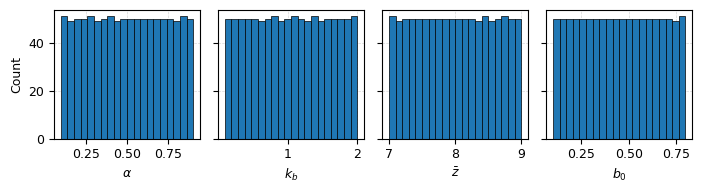

In [75]:
params = ["alpha_zre", "kb_zre", "zmean_zre", "b0_zre"]

labels = {
    "alpha_zre": r"$\alpha$",
    "kb_zre": r"$k_b$",
    "zmean_zre": r"$\bar{z}$",
    "b0_zre": r"$b_0$",
}

fig, axes = plt.subplots(1, 4, figsize=(7.1, 2.0), sharey=True)

for ax, param in zip(axes, params):
    ax.hist(df[param], bins=20, color='tab:blue', edgecolor='black', alpha=1.0, linewidth=0.5)
    
    ax.set_xlabel(labels[param])
    
    if ax == axes[0]:
        ax.set_ylabel("Count")
        
    ax.set_axisbelow(True)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()

fig.savefig(FIG_DIR / f"parameter_histograms_{EXPERIMENT_NAME}.pdf", format="pdf", bbox_inches="tight")
plt.show()

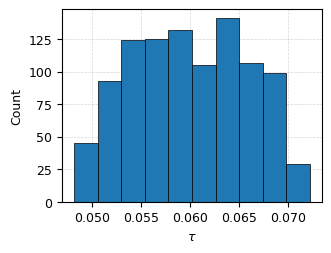

Mean: 0.0600 	 STD: 0.0058


In [76]:
fig, ax = plt.subplots()

ax.hist(df["tau"], bins=10, color='tab:blue', edgecolor="black", alpha=1.0, linewidth=0.5)

ax.set_xlabel(r"$\tau$")
ax.set_ylabel("Count")

ax.set_axisbelow(True)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

fig.savefig(
    FIG_DIR / f"tau_distribution_{EXPERIMENT_NAME}.pdf",
    format="pdf", 
    bbox_inches="tight"
)

plt.show()

print(f"Mean: {df["tau"].mean():.4f} \t STD: {df["tau"].std():.4f}")

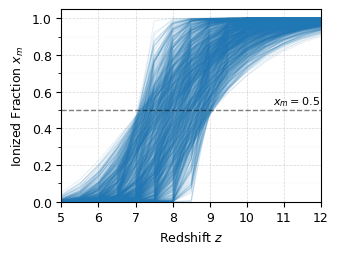

In [77]:
fig, ax = plt.subplots()

with h5py.File(H5_PATH, "r") as h5f:
    sims = h5f["sims"]
    for sim in sim_names:
        z = np.array(h5f[f"sims/{sim}/output/zval_list"][()], dtype=float)
        x = np.array(h5f[f"sims/{sim}/output/xmval_list"][()], dtype=float)
        z_order = np.argsort(z)
        z, x = z[z_order], x[z_order]
        
        ax.plot(z, x, color='tab:blue', lw=0.8, alpha=0.1)

ax.axhline(0.5, color="black", linestyle="--", lw=1.0, alpha=0.5)

ax.text(10.7, 0.53, r"$x_m = 0.5$", fontsize=8)

ax.set_xlabel("Redshift $z$")
ax.set_ylabel("Ionized Fraction $x_m$")

ax.xaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))

ax.set_axisbelow(True)
ax.grid(True, which="major", linestyle='--', linewidth=0.5, alpha=0.5)
ax.grid(True, which="minor", linestyle=':', linewidth=0.3, alpha=0.3)

ax.set_xlim(5, 12)
ax.set_ylim(0, 1.05)

fig.savefig(
    FIG_DIR / f"reionization_histories_{EXPERIMENT_NAME}.pdf",
    format="pdf",
    bbox_inches="tight",
)
plt.show()

## kSZ Map and Angular Power Spectrum

In [78]:
SIM_ID_1 = 100
SIM_ID_2 = 900

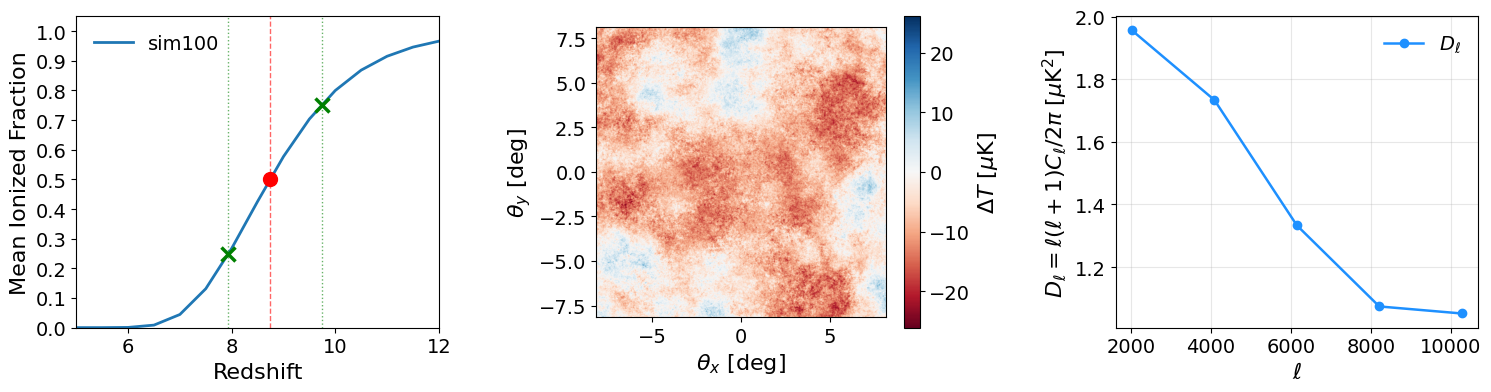

sim900: z50 = 8.75, dz(25-75) = 1.80


In [79]:
# SIM_ID_1
FS = 16  # fonts ~2x normal: figure prints at ~47% of this size in a 7" column

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

with h5py.File(H5_PATH, "r") as f:
    ksz_map0 = f["sims"][f"sim{SIM_ID_1}"]["output"]["ksz_map"][()]
    ell = f["sims"][f"sim{SIM_ID_1}"]["cl"]["ell"][()]
    dl = f["sims"][f"sim{SIM_ID_1}"]["cl"]["dl_ksz"][()]
    theta_max_ksz = f["sims"][f"sim{SIM_ID_1}"]["output"]["theta_max_ksz"][()]
    tcmb = float(f["sims"][f"sim{SIM_ID_1}"]["output"]["Tcmb0"][()])
    z = np.array(f["sims"][f"sim{SIM_ID_1}"]["output"]["zval_list"][()], dtype=float)
    x = np.array(f["sims"][f"sim{SIM_ID_1}"]["output"]["xmval_list"][()], dtype=float)

# Ionization History
order = np.argsort(z)
z, x = z[order], x[order]

# Reionization milestones (interpolated from the data)
z50 = np.interp(0.50, x, z)
z25 = np.interp(0.25, x, z)
z75 = np.interp(0.75, x, z)

ax[0].plot(z, x, lw=2, label=f"sim{SIM_ID_1}")

# 50% ionization
ax[0].axvline(z50, color="red", ls="--", lw=1.0, alpha=0.6)
ax[0].plot(z50, 0.50, marker="o", ms=10, color="red", ls="none", zorder=3)

# Duration from 25% to 75% ionized
ax[0].axvline(z25, color="green", ls=":", lw=1.0, alpha=0.6)
ax[0].axvline(z75, color="green", ls=":", lw=1.0, alpha=0.6)
ax[0].plot([z25, z75], [0.25, 0.75], marker="x", ms=10, mew=2.5,
           color="green", ls="none", zorder=3)

ax[0].set_xlim(5, 12)
ax[0].set_ylim(0, 1.05)
ax[0].yaxis.set_major_locator(MultipleLocator(0.1))

ax[0].set_xlabel("Redshift", fontsize=FS)
ax[0].set_ylabel("Mean Ionized Fraction", fontsize=FS)
# ax[0].set_title("Ionization History", fontsize=FS)
ax[0].legend(frameon=False, fontsize=FS - 2)
ax[0].tick_params(labelsize=FS - 2)


# kSZ Map
rescaled_map = ksz_map0 * tcmb * 1e6

tmax = np.amax(rescaled_map)
tmin = np.amin(rescaled_map)
textreme = max(tmax, np.abs(tmin))

theta_max_deg = np.rad2deg(theta_max_ksz)

extent = [
    -theta_max_deg / 2,
     theta_max_deg / 2,
    -theta_max_deg / 2,
     theta_max_deg / 2,
]

im = ax[1].imshow(
    rescaled_map,
    cmap="RdBu",
    vmin=-textreme,
    vmax=textreme,
    extent=extent,
    origin="lower",
    rasterized=True,
)

cb = fig.colorbar(im, ax=ax[1])
cb.set_label(r"$\Delta T$ [$\mu \mathrm{K}$]", fontsize=FS)
cb.ax.tick_params(labelsize=FS - 2)

ax[1].set_xlabel(r"$\theta_x$ [deg]", fontsize=FS)
ax[1].set_ylabel(r"$\theta_y$ [deg]", fontsize=FS)
# ax[1].set_title("kSZ Map", fontsize=FS)
ax[1].tick_params(labelsize=FS - 2)


# Angular Power Spectrum
ax[2].plot(ell, dl, marker="o", color="dodgerblue", lw=1.8, label=r"$D_\ell$")
ax[2].set_xlabel(r"$\ell$", fontsize=FS)
ax[2].set_ylabel(r"$D_\ell = \ell(\ell + 1)C_{\ell} / 2\pi$ [$\mu \mathrm{K}^2$]", fontsize=FS)
# ax[2].set_title("kSZ Rescaled Angular Power Spectrum", fontsize=FS - 2)
ax[2].grid(True, which="both", alpha=0.3)
ax[2].legend(frameon=False, fontsize=FS - 2)
ax[2].tick_params(labelsize=FS - 2)

fig.tight_layout(w_pad=3.0)
fig.savefig(
    FIG_DIR / f"ksz_map_spectrum_history_sim{SIM_ID_1}_{EXPERIMENT_NAME}.pdf",
    format="pdf",
    bbox_inches="tight",
)
plt.show()

print(f"sim{SIM_ID_2}: z50 = {z50:.2f}, dz(25-75) = {abs(z75 - z25):.2f}")

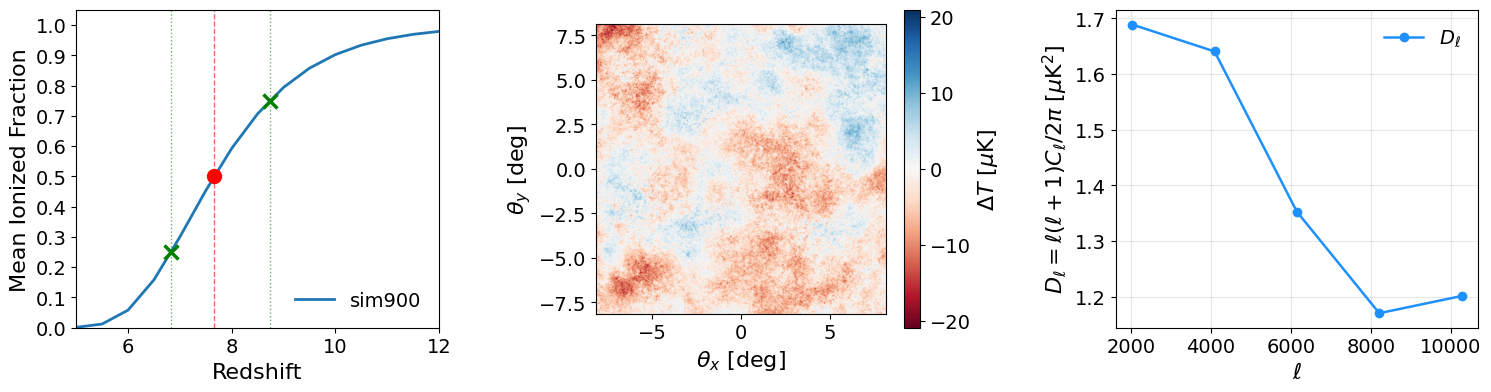

sim900: z50 = 7.67, dz(25-75) = 1.92


In [80]:
# SIM_ID_2
FS = 16  # fonts ~2x normal: figure prints at ~47% of this size in a 7" column

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

with h5py.File(H5_PATH, "r") as f:
    ksz_map0 = f["sims"][f"sim{SIM_ID_2}"]["output"]["ksz_map"][()]
    ell = f["sims"][f"sim{SIM_ID_2}"]["cl"]["ell"][()]
    dl = f["sims"][f"sim{SIM_ID_2}"]["cl"]["dl_ksz"][()]
    theta_max_ksz = f["sims"][f"sim{SIM_ID_2}"]["output"]["theta_max_ksz"][()]
    tcmb = float(f["sims"][f"sim{SIM_ID_2}"]["output"]["Tcmb0"][()])
    z = np.array(f["sims"][f"sim{SIM_ID_2}"]["output"]["zval_list"][()], dtype=float)
    x = np.array(f["sims"][f"sim{SIM_ID_2}"]["output"]["xmval_list"][()], dtype=float)

# Ionization History
order = np.argsort(z)
z, x = z[order], x[order]

# Reionization milestones (interpolated from the data)
z50 = np.interp(0.50, x, z)
z25 = np.interp(0.25, x, z)
z75 = np.interp(0.75, x, z)

ax[0].plot(z, x, lw=2, label=f"sim{SIM_ID_2}")

# 50% ionization
ax[0].axvline(z50, color="red", ls="--", lw=1.0, alpha=0.6)
ax[0].plot(z50, 0.50, marker="o", ms=10, color="red", ls="none", zorder=3)

# Duration from 25% to 75% ionized
ax[0].axvline(z25, color="green", ls=":", lw=1.0, alpha=0.6)
ax[0].axvline(z75, color="green", ls=":", lw=1.0, alpha=0.6)
ax[0].plot([z25, z75], [0.25, 0.75], marker="x", ms=10, mew=2.5,
           color="green", ls="none", zorder=3)

ax[0].set_xlim(5, 12)
ax[0].set_ylim(0, 1.05)
ax[0].yaxis.set_major_locator(MultipleLocator(0.1))

ax[0].set_xlabel("Redshift", fontsize=FS)
ax[0].set_ylabel("Mean Ionized Fraction", fontsize=FS)
# ax[0].set_title("Ionization History", fontsize=FS)
ax[0].legend(frameon=False, fontsize=FS - 2)
ax[0].tick_params(labelsize=FS - 2)


# kSZ Map
rescaled_map = ksz_map0 * tcmb * 1e6

tmax = np.amax(rescaled_map)
tmin = np.amin(rescaled_map)
textreme = max(tmax, np.abs(tmin))

theta_max_deg = np.rad2deg(theta_max_ksz)

extent = [
    -theta_max_deg / 2,
     theta_max_deg / 2,
    -theta_max_deg / 2,
     theta_max_deg / 2,
]

im = ax[1].imshow(
    rescaled_map,
    cmap="RdBu",
    vmin=-textreme,
    vmax=textreme,
    extent=extent,
    origin="lower",
    rasterized=True,
)

cb = fig.colorbar(im, ax=ax[1])
cb.set_label(r"$\Delta T$ [$\mu \mathrm{K}$]", fontsize=FS)
cb.ax.tick_params(labelsize=FS - 2)

ax[1].set_xlabel(r"$\theta_x$ [deg]", fontsize=FS)
ax[1].set_ylabel(r"$\theta_y$ [deg]", fontsize=FS)
# ax[1].set_title("kSZ Map", fontsize=FS)
ax[1].tick_params(labelsize=FS - 2)


# Angular Power Spectrum
ax[2].plot(ell, dl, marker="o", color="dodgerblue", lw=1.8, label=r"$D_\ell$")
ax[2].set_xlabel(r"$\ell$", fontsize=FS)
ax[2].set_ylabel(r"$D_\ell = \ell(\ell + 1)C_{\ell} / 2\pi$ [$\mu \mathrm{K}^2$]", fontsize=FS)
# ax[2].set_title("kSZ Rescaled Angular Power Spectrum", fontsize=FS - 2)
ax[2].grid(True, which="both", alpha=0.3)
ax[2].legend(frameon=False, fontsize=FS - 2)
ax[2].tick_params(labelsize=FS - 2)

fig.tight_layout(w_pad=3.0)
fig.savefig(
    FIG_DIR / f"ksz_map_spectrum_history_sim{SIM_ID_2}_{EXPERIMENT_NAME}.pdf",
    format="pdf",
    bbox_inches="tight",
)
plt.show()

print(f"sim{SIM_ID_2}: z50 = {z50:.2f}, dz(25-75) = {abs(z75 - z25):.2f}")

sim100: z50 = 8.75, dz(25-75) = 1.80
sim900: z50 = 7.67, dz(25-75) = 1.92


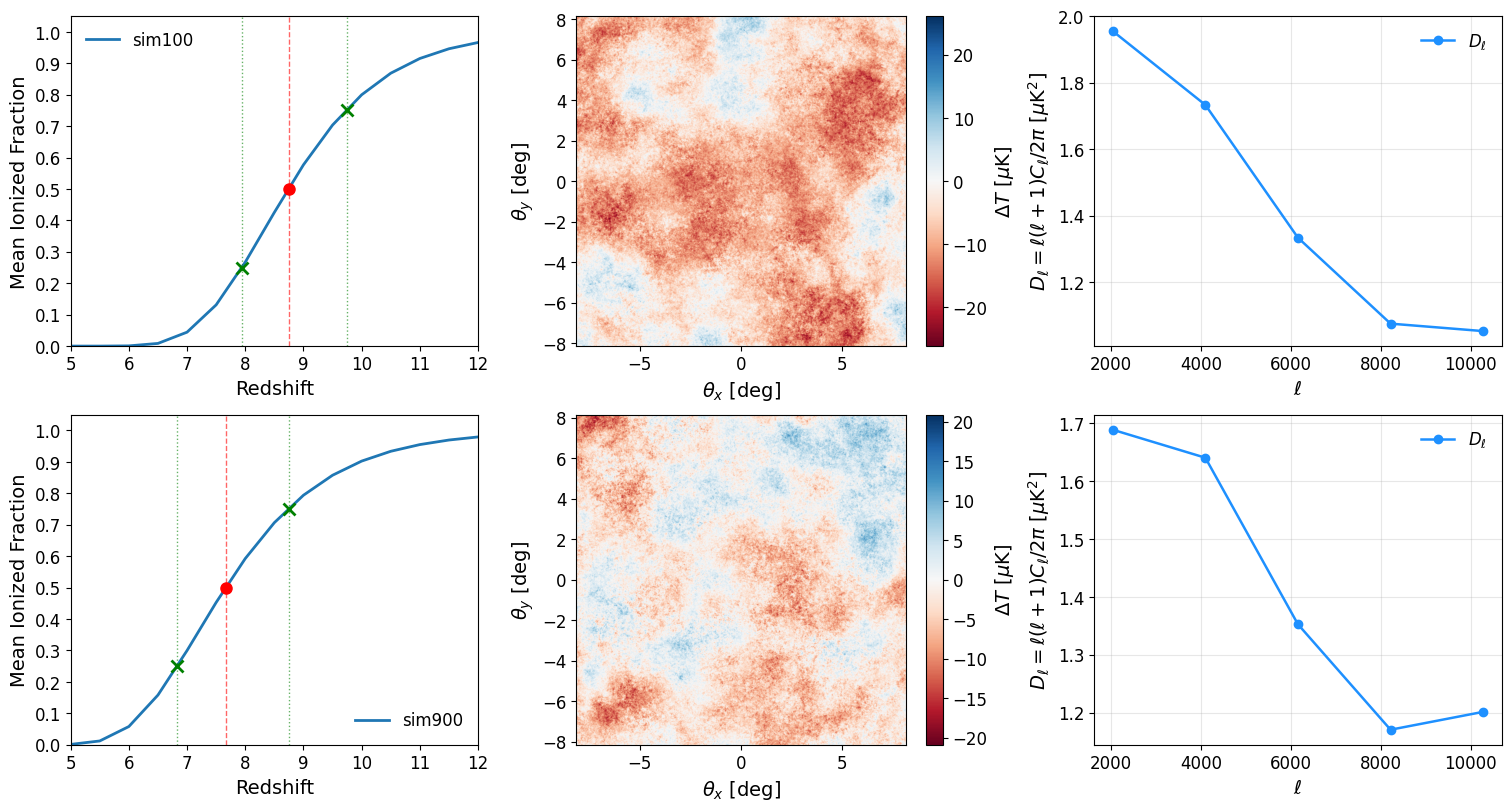

In [81]:
FS = 14

sim_ids = [SIM_ID_1, SIM_ID_2]

fig, ax = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)


def plot_simulation_row(row, sim_id):
    with h5py.File(H5_PATH, "r") as f:
        ksz_map0 = f["sims"][f"sim{sim_id}"]["output"]["ksz_map"][()]
        ell = f["sims"][f"sim{sim_id}"]["cl"]["ell"][()]
        dl = f["sims"][f"sim{sim_id}"]["cl"]["dl_ksz"][()]
        theta_max_ksz = f["sims"][f"sim{sim_id}"]["output"]["theta_max_ksz"][()]
        tcmb = float(f["sims"][f"sim{sim_id}"]["output"]["Tcmb0"][()])
        z = np.array(f["sims"][f"sim{sim_id}"]["output"]["zval_list"][()], dtype=float)
        x = np.array(f["sims"][f"sim{sim_id}"]["output"]["xmval_list"][()], dtype=float)

    # Sort by redshift for plotting
    order = np.argsort(z)
    z, x = z[order], x[order]

    # Sort by ionized fraction for interpolation
    interp_order = np.argsort(x)
    x_interp = x[interp_order]
    z_interp = z[interp_order]

    z50 = np.interp(0.50, x_interp, z_interp)
    z25 = np.interp(0.25, x_interp, z_interp)
    z75 = np.interp(0.75, x_interp, z_interp)

    # -------------------------
    # Ionization history
    # -------------------------
    ax[row, 0].plot(z, x, lw=2, label=f"sim{sim_id}")

    ax[row, 0].axvline(z50, color="red", ls="--", lw=1.0, alpha=0.6)
    ax[row, 0].plot(z50, 0.50, marker="o", ms=8, color="red", ls="none", zorder=3)

    ax[row, 0].axvline(z25, color="green", ls=":", lw=1.0, alpha=0.6)
    ax[row, 0].axvline(z75, color="green", ls=":", lw=1.0, alpha=0.6)
    ax[row, 0].plot(
        [z25, z75],
        [0.25, 0.75],
        marker="x",
        ms=8,
        mew=2.0,
        color="green",
        ls="none",
        zorder=3,
    )

    ax[row, 0].set_xlim(5, 12)
    ax[row, 0].set_ylim(0, 1.05)
    ax[row, 0].yaxis.set_major_locator(MultipleLocator(0.1))
    ax[row, 0].set_xlabel("Redshift", fontsize=FS)
    ax[row, 0].set_ylabel("Mean Ionized Fraction", fontsize=FS)
    ax[row, 0].legend(frameon=False, fontsize=FS - 2)
    ax[row, 0].tick_params(labelsize=FS - 2)

    # -------------------------
    # kSZ map
    # -------------------------
    rescaled_map = ksz_map0 * tcmb * 1e6

    tmax = np.amax(rescaled_map)
    tmin = np.amin(rescaled_map)
    textreme = max(tmax, np.abs(tmin))

    theta_max_deg = np.rad2deg(theta_max_ksz)

    extent = [
        -theta_max_deg / 2,
         theta_max_deg / 2,
        -theta_max_deg / 2,
         theta_max_deg / 2,
    ]

    im = ax[row, 1].imshow(
        rescaled_map,
        cmap="RdBu",
        vmin=-textreme,
        vmax=textreme,
        extent=extent,
        origin="lower",
        rasterized=True,
    )

    cb = fig.colorbar(im, ax=ax[row, 1])
    cb.set_label(r"$\Delta T$ [$\mu \mathrm{K}$]", fontsize=FS)
    cb.ax.tick_params(labelsize=FS - 2)

    ax[row, 1].set_xlabel(r"$\theta_x$ [deg]", fontsize=FS)
    ax[row, 1].set_ylabel(r"$\theta_y$ [deg]", fontsize=FS)
    ax[row, 1].tick_params(labelsize=FS - 2)

    # -------------------------
    # Angular power spectrum
    # -------------------------
    ax[row, 2].plot(ell, dl, marker="o", color="dodgerblue", lw=1.8, label=r"$D_\ell$")
    ax[row, 2].set_xlabel(r"$\ell$", fontsize=FS)
    ax[row, 2].set_ylabel(
        r"$D_\ell = \ell(\ell + 1)C_{\ell} / 2\pi$ [$\mu \mathrm{K}^2$]",
        fontsize=FS,
    )
    ax[row, 2].grid(True, which="both", alpha=0.3)
    ax[row, 2].legend(frameon=False, fontsize=FS - 2)
    ax[row, 2].tick_params(labelsize=FS - 2)

    return z50, abs(z75 - z25)


for row, sim_id in enumerate(sim_ids):
    z50, dz = plot_simulation_row(row, sim_id)
    print(f"sim{sim_id}: z50 = {z50:.2f}, dz(25-75) = {dz:.2f}")


fig.savefig(
    FIG_DIR / f"ksz_map_spectrum_history_stacked_sim{SIM_ID_1}_sim{SIM_ID_2}_{EXPERIMENT_NAME}.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()